<a href="https://colab.research.google.com/github/dhsf1-ua/tfg-dhsf-restauracion/blob/main/TFG_analisis_Alicante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1


# 1. Carga y Preparación Inicial de los Datos

En esta primera sección, establecemos la conexión con Google Drive para importar los conjuntos de datos extraídos mediante la API de Google Places.

El objetivo es cargar los datos de las dos ciudades bajo estudio (Alicante y Elche) y combinarlos en dos *DataFrames* principales de Pandas:
* `df_restaurantes`: Contiene la información estructural y métricas de los establecimientos (coordenadas, precio, nota media).
* `df_reviews`: Contiene el texto de las opiniones individuales para el futuro análisis de Procesamiento de Lenguaje Natural (NLP).

In [ ]:
# ==========================================
# CELDA 1: CONEXIÓN A DRIVE Y CARGA DE DATOS
# ==========================================
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

ruta_base = '/content/drive/MyDrive/TFG/'

df_rest_ali = pd.read_csv(ruta_base + 'dataset_restaurantes_alicante.csv')
df_rest_elx = pd.read_csv(ruta_base + 'dataset_restaurantes_elche.csv')

df_rest_ali['ciudad'] = 'Alicante'
df_rest_elx['ciudad'] = 'Elche'

df_restaurantes = pd.concat([df_rest_ali, df_rest_elx], ignore_index=True)

df_rev_ali = pd.read_csv(ruta_base + 'dataset_reviews_alicante.csv')
df_rev_elx = pd.read_csv(ruta_base + 'dataset_reviews_elche.csv')

df_rev_ali['ciudad'] = 'Alicante'
df_rev_elx['ciudad'] = 'Elche'

df_reviews = pd.concat([df_rev_ali, df_rev_elx], ignore_index=True)

print("--- RESUMEN DE DATOS CARGADOS ---")
print(f"Total Restaurantes: {df_restaurantes.shape[0]} ({len(df_rest_ali)} en Alicante, {len(df_rest_elx)} en Elche)")
print(f"Total Reseñas: {df_reviews.shape[0]} ({len(df_rev_ali)} en Alicante, {len(df_rev_elx)} en Elche)")

display(df_restaurantes.head(3))

Mounted at /content/drive
--- RESUMEN DE DATOS CARGADOS ---
Total Restaurantes: 2923 (2238 en Alicante, 685 en Elche)
Total Reseñas: 13135 (10015 en Alicante, 3120 en Elche)


,place_id,name,address,lat,lng,types,rating,user_ratings_total,price_level,website,phone,summary,ciudad
0,ChIJAbyX-uY7Yg0RjlGWdGXAa5A,DIDIER NAPOLETANO,"C. de Sant Vicent, 113, 03560 El Campello, Ali...",38.418875,-0.391752,establishment;food;point_of_interest;restaurant,NaN,NaN,NaN,NaN,865 88 53 69,NaN,Alicante
1,ChIJRakVw7I3Yg0RmkHAdZESo0Y,Pinetell vins i tapes Alacant,"C/ Navas, 21, 03001 Alacant, Alicante, España",38.345334,-0.487060,bar;establishment;food;point_of_interest;resta...,4.5,264.0,1.0,NaN,601 42 60 11,NaN,Alicante
2,ChIJ_S7-aEw2Yg0RNsZtKOpvkRw,L'arruzz - Alicante,"Carrer Portugal, 29, 03003 Alacant, Alicante, ...",38.342580,-0.490870,bar;establishment;food;point_of_interest;resta...,4.3,3014.0,2.0,http://www.larruzzalicante.com/,965 12 20 98,Mesón y barra con decoración contemporánea de ...,Alicante


## Imports

In [ ]:
# ==========================================
# IMPORTS GLOBALES — Ejecutar si hay errores de NameError
# ==========================================

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import folium
from folium.plugins import HeatMap, MarkerCluster

try:
    from groq import Groq
except ImportError:
    print("Groq no instalado, no necesario si la categorización ya está hecha")

import os
import time

print("Todos los imports cargados correctamente")

# 2. Limpieza de Datos (Data Cleaning)

Una vez cargados los datos, el siguiente paso es explorar el conjunto y garantizar su calidad. En esta fase trataremos con los valores ausentes (NaN) y los registros duplicados.

Dado el valor de la información geoespacial, evitaremos eliminar filas enteras mediante `dropna()`. En su lugar, aplicaremos estrategias de **imputación**:
* **Nivel de precio (`price_level`)**: Imputaremos los valores nulos utilizando la mediana de la ciudad correspondiente para mantener la coherencia estadística.
* **Valoraciones (`rating` y `user_ratings_total`)**: Asumiremos un valor de 0 para aquellos locales sin interacciones.
* **Datos de texto (`website`, `summary`)**: Sustituiremos los valores nulos por la cadena "Sin datos".

Por último, normalizaremos las categorías de la columna `types` (pasando a minúsculas y limpiando separadores) para facilitar el filtrado posterior.

In [ ]:
print("--- NULOS ANTES DE LA LIMPIEZA ---")
nulos_previos = df_restaurantes.isnull().sum()
print(nulos_previos[nulos_previos > 0])

# Eliminacion de duplicados
df_restaurantes = df_restaurantes.drop_duplicates(subset=['place_id'])

# Imputacion de precio
df_restaurantes['price_level'] = df_restaurantes.groupby('ciudad')['price_level'].transform(lambda x: x.fillna(x.median()))

df_restaurantes['user_ratings_total'] = df_restaurantes['user_ratings_total'].fillna(0)

df_restaurantes['website'] = df_restaurantes['website'].fillna('Sin datos')
df_restaurantes['summary'] = df_restaurantes['summary'].fillna('Sin datos')
df_restaurantes['phone'] = df_restaurantes['phone'].fillna('Sin datos')

df_restaurantes['types'] = df_restaurantes['types'].str.lower().str.replace(';', ', ')

print("\n--- NULOS DESPUES DE LA LIMPIEZA ---")
nulos_post = df_restaurantes.isnull().sum()
print(nulos_post[nulos_post > 0])

--- NULOS ANTES DE LA LIMPIEZA ---
place_id                 1
name                     1
address                  1
lat                      1
lng                      1
types                    1
rating                 186
user_ratings_total     186
price_level           1634
website               1416
phone                  417
summary               2581
dtype: int64

--- NULOS DESPUES DE LA LIMPIEZA ---
place_id      1
name          1
address       1
lat           1
lng           1
types         1
rating      186
dtype: int64


# 3. Exploración y Diccionario de Datos

Tras la limpieza, es fundamental comprender la estructura de la información con la que vamos a trabajar. Hemos construido un modelo de datos relacional compuesto por dos *DataFrames* vinculados por el campo `place_id`.

### A. Dataset Principal: `df_restaurantes`
Contiene la información estructural y las métricas globales de cada establecimiento (1 fila = 1 restaurante).
* **place_id**: Identificador alfanumérico único de Google Maps (Clave Primaria).
* **name**: Nombre comercial del establecimiento.
* **address**: Dirección postal completa.
* **lat / lng**: Coordenadas geográficas (Latitud y Longitud) para el análisis espacial.
* **types**: Categorías del local (ej. restaurant, bar, cafe).
* **rating**: Nota media global. **Dato de tipo Float** (Escala decimal 1.0 - 5.0).
* **user_ratings_total**: Volumen total de reseñas recibidas.
* **price_level**: Nivel de precio estimado (0: Gratis, 1: Barato, 2: Moderado, 3: Caro, 4: Muy caro).
* **website / phone**: Datos de contacto y presencia digital.
* **summary**: Resumen editorial proporcionado por Google.
* **ciudad**: Etiqueta añadida para diferenciar "Alicante" de "Elche".

### B. Dataset de Detalle: `df_reviews`
Contiene el texto de las reseñas individuales para el análisis cualitativo y de Procesamiento de Lenguaje Natural (Múltiples filas por restaurante).
* **place_id**: Identificador del restaurante (Clave Foránea).
* **author_name**: Nombre del usuario que publica la opinión.
* **rating**: Nota individual otorgada por el usuario. **Dato de tipo Integer** (Valores enteros del 1 al 5).
* **text**: Contenido íntegro de la reseña.
* **time / relative_time**: Fecha de publicación (Timestamp y formato relativo).
* **ciudad**: Ubicación del restaurante reseñado.

In [ ]:
df_restaurantes.dropna(subset=['place_id'], inplace=True)
df_reviews.dropna(subset=['place_id'], inplace=True)

print("=== ESTRUCTURA FINAL DE LOS DATASETS ===")
print(f"Dataset Restaurantes: {df_restaurantes.shape[0]} filas, {df_restaurantes.shape[1]} columnas")
print(f"Dataset Resenas:      {df_reviews.shape[0]} filas, {df_reviews.shape[1]} columnas\n")

pd.set_option('display.max_columns', None)

print("--- EJEMPLO DE RESTAURANTES (Muestra aleatoria de 3 locales) ---")
display(df_restaurantes.sample(3))

print("\n--- EJEMPLO DE RESENAS (Primeras 3 opiniones) ---")
display(df_reviews.head(3))

pd.reset_option('display.max_columns')

=== ESTRUCTURA FINAL DE LOS DATASETS ===
Dataset Restaurantes: 2922 filas, 13 columnas
Dataset Resenas:      13135 filas, 7 columnas

--- EJEMPLO DE RESTAURANTES (Muestra aleatoria de 3 locales) ---


,place_id,name,address,lat,lng,types,rating,user_ratings_total,price_level,website,phone,summary,ciudad
433,ChIJCeadcwA7Yg0R-wKgSla79Pg,Restaurante chino San Bartolomé,"C. Sant Bartomeu, 03560 El Campello, Alicante,...",38.427100,-0.390939,"establishment, food, point_of_interest, restau...",NaN,0.0,1.0,Sin datos,Sin datos,Sin datos,Alicante
2657,ChIJy-7dJLO3Yw0R4z_DYLmcfRQ,Meat Brother,"Carrer Baltasar Brotons Garcia, 03202 Elx, Ali...",38.269822,-0.677377,"establishment, food, point_of_interest, restau...",NaN,0.0,1.0,Sin datos,660 15 06 63,Sin datos,Elche
2895,ChIJo8JUVbW3Yw0R_d4Ge0p0eyA,Restaurante asiático GENKI,"Carrer Ruperto Chapí, 40, 03201 Elx, Alicante,...",38.267534,-0.703073,"establishment, food, point_of_interest, restau...",4.9,485.0,1.0,Sin datos,643 06 32 35,Sin datos,Elche



--- EJEMPLO DE RESENAS (Primeras 3 opiniones) ---


,place_id,author_name,rating,text,time,relative_time,ciudad
0,ChIJRakVw7I3Yg0RmkHAdZESo0Y,Marina,5,El señor que nos atendió fue encantador! Ademá...,1675120516,Hace 3 años,Alicante
1,ChIJRakVw7I3Yg0RmkHAdZESo0Y,Angela Jimenez,5,El propietario es encantador. La comida súper ...,1648728921,Hace 3 años,Alicante
2,ChIJRakVw7I3Yg0RmkHAdZESo0Y,Laura Garcia Alberola,4,"Pequeñito pero matón, hacen l mejor tortilla ...",1622279203,Hace 4 años,Alicante


# 4. Estadística Descriptiva (Tendencia Central y Dispersión)

En esta fase aplicaremos técnicas de estadística descriptiva para comprender el comportamiento de las variables numéricas clave (`rating`, `price_level`, `user_ratings_total`).

Metodológicamente, dividiremos este análisis en tres partes:
1. **Análisis Individual por Ciudad:** Utilizaremos la función `describe()` para obtener una visión completa de la tendencia central (media, mediana) y la dispersión (desviación estándar, valores mínimos, máximos y cuartiles) de Alicante y Elche por separado. Además, calcularemos el coeficiente de asimetría (*skewness*) para entender hacia dónde se inclinan las valoraciones.
2. **Comparativa Agrupada:** Confrontaremos directamente las medias y medianas de ambas ciudades para extraer conclusiones de negocio.
3. **Discretización de Datos Continuos:** Utilizaremos la técnica de discretización basada en cuantiles (`qcut`) para agrupar a los restaurantes en tres categorías ("Bajo", "Medio" y "Alto" volumen de reseñas), analizando cómo se distribuye esta popularidad en ambas poblaciones.

In [ ]:
import pandas as pd
from scipy import stats

# Recreamos los subsets con el dataset ya limpio y enriquecido
df_ali = df_restaurantes[df_restaurantes['ciudad'] == 'Alicante']
df_elx = df_restaurantes[df_restaurantes['ciudad'] == 'Elche']
metricas = ['rating', 'price_level', 'user_ratings_total']

print("=== 1. ALICANTE ===")
display(df_ali[metricas].describe().round(2))
asimetria_ali = stats.skew(df_ali['rating'].dropna())
print(f"Asimetria (Skewness) del rating en Alicante: {asimetria_ali:.2f}\n")

print("=== 2. ELCHE ===")
display(df_elx[metricas].describe().round(2))
asimetria_elx = stats.skew(df_elx['rating'].dropna())
print(f"Asimetria (Skewness) del rating en Elche: {asimetria_elx:.2f}\n")

print("=== 3. COMPARATIVA DIRECTA (Agrupada) ===")
estadisticas_comparativas = df_restaurantes.groupby('ciudad')[metricas].agg(['mean', 'median', 'std']).round(2)
display(estadisticas_comparativas)

print("\n=== 4. VOLUMEN DE RESEÑAS ===")
df_restaurantes['volumen_resenas_cat'] = pd.qcut(
    df_restaurantes['user_ratings_total'],
    q=3,
    labels=['Volumen Bajo', 'Volumen Medio', 'Volumen Alto']
)
distribucion_resenas = pd.crosstab(df_restaurantes['ciudad'], df_restaurantes['volumen_resenas_cat'])
display(distribucion_resenas)

=== 1. ALICANTE ===


,rating,price_level,user_ratings_total
count,2091.00,2237.00,2237.00
mean,4.32,1.16,623.63
std,0.50,0.39,1299.65
min,1.00,1.00,0.00
25%,4.10,1.00,49.00
50%,4.40,1.00,232.00
75%,4.70,1.00,718.00
max,5.00,4.00,30028.00


Asimetria (Skewness) del rating en Alicante: -1.80

=== 2. ELCHE ===


,rating,price_level,user_ratings_total
count,646.00,685.00,685.00
mean,4.28,1.12,456.68
std,0.51,0.35,783.10
min,1.00,1.00,0.00
25%,4.10,1.00,40.00
50%,4.30,1.00,174.00
75%,4.60,1.00,525.00
max,5.00,4.00,7481.00


Asimetria (Skewness) del rating en Elche: -1.90

=== 3. COMPARATIVA DIRECTA (Agrupada) ===


rating              price_level              user_ratings_total  \
           mean median   std        mean median   std               mean   
ciudad                                                                     
Alicante   4.32    4.4  0.50        1.16    1.0  0.39             623.63   
Elche      4.28    4.3  0.51        1.12    1.0  0.35             456.68   

                          
         median      std  
ciudad                    
Alicante  232.0  1299.65  
Elche     174.0   783.10


=== 4. VOLUMEN DE RESEÑAS ===


volumen_resenas_cat,Volumen Bajo,Volumen Medio,Volumen Alto
ciudad,,,
Alicante,722,731,784
Elche,253,242,190


In [ ]:
import plotly.express as px

# Filtramos los nulos para evitar errores
df_hist = df_restaurantes[df_restaurantes['rating'].notna()]

fig = px.histogram(
    df_hist,
    x='rating',
    color='ciudad',
    barmode='overlay',
    histnorm='percent', # CLAVE 1: Normaliza para comparar muestras de distinto tamaño
    marginal='box',     # CLAVE 2: Añade el boxplot arriba para ver el skewness y la mediana
    nbins=25,
    opacity=0.75,
    title='Distribución Porcentual del Rating por Ciudad',
    labels={
        'rating': 'Rating (Nota media)',
        'percent': 'Porcentaje de restaurantes (%)',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(range=[0.8, 5.2]), # CLAVE 3: Centra el gráfico en la escala real
    yaxis_title='Porcentaje del total de la ciudad (%)',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1) # Sube la leyenda para que no tape los datos
)

fig.show()

In [ ]:
print(pd.qcut(df_restaurantes['user_ratings_total'], q=3,
      labels=['Volumen Bajo', 'Volumen Medio', 'Volumen Alto']).cat.categories)

Index(['Volumen Bajo', 'Volumen Medio', 'Volumen Alto'], dtype='object')


In [ ]:
print("Umbrales de los terciles por ciudad:")
for ciudad in ['Alicante', 'Elche']:
    subset = df_restaurantes[df_restaurantes['ciudad'] == ciudad]['user_ratings_total'].dropna()
    q33 = subset.quantile(0.33)
    q66 = subset.quantile(0.66)
    print(f"\n{ciudad}:")
    print(f"  Volumen Bajo:  0 - {q33:.0f} reseñas")
    print(f"  Volumen Medio: {q33:.0f} - {q66:.0f} reseñas")
    print(f"  Volumen Alto:  más de {q66:.0f} reseñas")

Umbrales de los terciles por ciudad:

Alicante:
  Volumen Bajo:  0 - 96 reseñas
  Volumen Medio: 96 - 487 reseñas
  Volumen Alto:  más de 487 reseñas

Elche:
  Volumen Bajo:  0 - 70 reseñas
  Volumen Medio: 70 - 380 reseñas
  Volumen Alto:  más de 380 reseñas


# 5. Visualización Interactiva y Análisis Espacial

A nivel macroestadístico, Alicante y Elche presentan una distribución de valoraciones prácticamente idéntica. Por tanto, el factor diferencial no reside en el "cuánto" sino en el "dónde".

Para explorar esta dimensión espacial y la distribución cualitativa, evolucionaremos los métodos estáticos tradicionales (como diagramas de dispersión y caja) hacia tecnologías de visualización interactiva:
1. **Análisis de Dispersión Interactivo (Plotly):** Analizaremos la relación entre el volumen de reseñas, la nota y el precio, permitiendo la exploración individualizada de cada local.
2. **Análisis Geoespacial (Folium):** Renderizaremos un mapa de calor combinado con un algoritmo de agrupación (*Clustering*) para identificar no solo las zonas de mayor densidad de restauración, sino la ubicación exacta de los establecimientos "Top".

In [ ]:
import plotly.express as px

print("=== 1. DISPERSION INTERACTIVA (Votos vs Nota) ===")

umbral_votos = df_restaurantes['user_ratings_total'].quantile(0.25)
print(f"Umbral de fiabilidad calculado (Percentil 25): {umbral_votos} resenas minimas.")

df_filtrado = df_restaurantes[
    (df_restaurantes['user_ratings_total'] > umbral_votos) &
    (df_restaurantes['rating'].notnull())
].copy()

# Rellenamos los NaN de price_level con 1 solo para el tamaño del punto
df_filtrado['price_level_viz'] = df_filtrado['price_level'].fillna(1)

fig = px.scatter(
    df_filtrado,
    x='user_ratings_total',
    y='rating',
    color='ciudad',
    size='price_level_viz',
    hover_name='name',
    hover_data=['types', 'price_level'],
    opacity=0.7,
    title=f'Relacion entre Popularidad y Calidad (Filtrado > {int(umbral_votos)} reseñas)',
    labels={'user_ratings_total': 'Total de Resenas', 'rating': 'Nota Media (1-5)', 'ciudad': 'Ciudad'},
    color_discrete_sequence=['#33C1FF', '#FF5733']
)

fig.update_layout(plot_bgcolor='white', hoverlabel=dict(bgcolor="white", font_size=14))
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')
fig.show()
fig.update_layout(width=900, height=600) # Fijar proporciones A4
fig.write_image("scatter_popularidad_calidad.png", scale=4)

=== 1. DISPERSION INTERACTIVA (Votos vs Nota) ===
Umbral de fiabilidad calculado (Percentil 25): 44.0 resenas minimas.


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
import folium
from folium.plugins import HeatMap, MarkerCluster

print("=== 2. MAPA GEOESPACIAL: DENSIDAD Y 'TOP' RESTAURANTES ===")

centro_lat = df_restaurantes['lat'].mean()
centro_lng = df_restaurantes['lng'].mean()

mapa_geo = folium.Map(
    location=[centro_lat, centro_lng],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

coordenadas_calor = df_restaurantes[['lat', 'lng']].dropna().values.tolist()
HeatMap(
    coordenadas_calor,
    radius=12, blur=10,
    gradient={0.4: 'blue', 0.6: 'lime', 1: 'red'},
    name='Densidad Total'
).add_to(mapa_geo)

# Filtramos solo los que tienen rating, reseñas Y price_level válidos
top_restaurantes = df_restaurantes[
    (df_restaurantes['rating'] >= 4.7) &
    (df_restaurantes['user_ratings_total'] >= 500) &
    (df_restaurantes['price_level'].notna())
]

cluster_top = MarkerCluster(name='Top Restaurantes (Clickables)').add_to(mapa_geo)

for index, row in top_restaurantes.iterrows():
    popup_html = (
        f"<b>{row['name']}</b><br>"
        f"Nota: {row['rating']} ⭐<br>"
        f"Resenas: {int(row['user_ratings_total'])}<br>"
        f"Precio: Nivel {int(row['price_level'])}"
    )
    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color='orange', icon='star', prefix='fa')
    ).add_to(cluster_top)

folium.LayerControl().add_to(mapa_geo)
display(mapa_geo)

=== 2. MAPA GEOESPACIAL: DENSIDAD Y 'TOP' RESTAURANTES ===


In [ ]:
import plotly.express as px

print("=== MAPA TERMICO DE ALTA RESOLUCION: ALICANTE Y ELCHE ===")

centro_lat = df_restaurantes['lat'].mean()
centro_lng = df_restaurantes['lng'].mean()

fig_map = px.density_mapbox(
    df_restaurantes,
    lat='lat',
    lon='lng',
    z='rating',
    radius=10,
    center=dict(lat=centro_lat, lon=centro_lng),
    zoom=10.5,
    mapbox_style="carto-darkmatter",
    color_continuous_scale="Inferno",
    title="Focos de Alta Calidad Gastronomica (Basado en Rating) - Alicante y Elche",
    hover_name="name",
    hover_data={'lat': False, 'lng': False, 'rating': True, 'ciudad': True, 'types': True}
)

fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_map.show()

=== MAPA TERMICO DE ALTA RESOLUCION: ALICANTE Y ELCHE ===


In [ ]:
import plotly.express as px

df_mapa_limpio = df_restaurantes[df_restaurantes['rating'].notna()]

fig_mapa = px.density_mapbox(
    df_mapa_limpio,
    lat='lat',
    lon='lng',
    z='rating',
    radius=9,
    zoom=11.5,
    mapbox_style='carto-positron',
    color_continuous_scale='YlOrRd',
    title='Focos de Alta Calidad Gastronómica (Basado en Rating) - Alicante y Elche',
    labels={'z': 'Rating'}
)

fig_mapa.update_layout(
    height=600,
    margin=dict(l=20, r=20, t=60, b=20), a
    coloraxis_colorbar=dict(
        title='Rating',
        thicknessmode="pixels", thickness=15,
        lenmode="pixels", len=400,
        yanchor="top", y=1,
        ticks="outside"
    ),
    title=dict(
        y=0.95, x=0.5, xanchor='center'
    )
)

fig_mapa.show()

# 6. Análisis Categórico Interactivo y Nube de Palabras (NLP Preview)

Para concluir la fase de visualización, aplicaremos dos técnicas avanzadas para extraer valor de las categorías y del texto libre:

1. **Diagrama de Árbol Interactivo (Plotly Treemap):** Evolucionando desde los gráficos estáticos tradicionales, desglosaremos la columna `types` (filtrando previamente etiquetas genéricas) mediante un *Treemap* interactivo. Esto nos permitirá explorar la proporción de cada tipología gastronómica haciendo *zoom* dinámico entre Alicante y Elche.
2. **Nube de Palabras (Word Cloud):** Como paso previo al análisis profundo de Procesamiento de Lenguaje Natural (NLP), procesaremos las reseñas de los clientes (`df_reviews`). Filtraremos las palabras vacías (stopwords) en español para revelar visualmente los términos más frecuentes que utilizan los usuarios al describir sus experiencias.

In [ ]:
import plotly.express as px
import pandas as pd

print("=== DIAGRAMA DE ARBOL: ALICANTE VS ELCHE (CLICK PARA ZOOM) ===")

# 1. Separacion de categorias multiples en filas individuales
df_exploded = df_restaurantes.assign(tipo_individual=df_restaurantes['types'].str.split(', ')).explode('tipo_individual')

# 2. Limpieza de etiquetas sin valor analitico
etiquetas_basura = ['point_of_interest', 'establishment', 'food', 'restaurant', 'store']
df_tipos_limpio = df_exploded[~df_exploded['tipo_individual'].isin(etiquetas_basura)]

# 3. Agrupacion por CIUDAD y tipo de restaurante
conteo_tipos = df_tipos_limpio.groupby(['ciudad', 'tipo_individual']).size().reset_index(name='total')
conteo_tipos = conteo_tipos[conteo_tipos['total'] > 15]

fig_tree = px.treemap(
    conteo_tipos,
    path=[px.Constant("Oferta Gastronomica"), 'ciudad', 'tipo_individual'],
    values='total',
    color='total',
    color_continuous_scale='Teal',
    title='Tipologias de Restaurantes: Alicante vs Elche'
)

fig_tree.update_traces(root_color="lightgrey")
fig_tree.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig_tree.show()

=== DIAGRAMA DE ARBOL: ALICANTE VS ELCHE (CLICK PARA ZOOM) ===


In [ ]:
import plotly.express as px
import pandas as pd

print("=== DIAGRAMA DE ÁRBOL: ALICANTE VS ELCHE (CLICK PARA ZOOM) ===")

df_exploded = df_restaurantes.assign(tipo_individual=df_restaurantes['types'].str.split(', ')).explode('tipo_individual')

# 2. Limpieza de etiquetas
etiquetas_basura = ['point_of_interest', 'establishment', 'food', 'restaurant', 'store']
df_tipos_limpio = df_exploded[~df_exploded['tipo_individual'].isin(etiquetas_basura)]

# 3. Agrupación por CIUDAD y tipo de restaurante
conteo_tipos = df_tipos_limpio.groupby(['ciudad', 'tipo_individual']).size().reset_index(name='total')
conteo_tipos = conteo_tipos[conteo_tipos['total'] > 15]

fig_tree = px.treemap(
    conteo_tipos,
    path=[px.Constant("Oferta Gastronómica"), 'ciudad', 'tipo_individual'],
    values='total',
    color='ciudad',
    color_discrete_map={
        'Alicante': '#1f77b4', # Azul
        'Elche': '#ff7f0e',    # Naranja
        '(?)': '#e5ecf6'
    },
    title='Jerarquía de Tipologías Comerciales de Google: Alicante vs Elche'
)


fig_tree.update_traces(
    textinfo="label+value",
    textfont=dict(size=14, color="white"),
    marker=dict(line=dict(color='white', width=2)),
    hovertemplate='<b>%{label}</b><br>Total Locales: %{value}<br>Ciudad: %{parent}<extra></extra>'
)

fig_tree.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig_tree.show()

=== DIAGRAMA DE ÁRBOL: ALICANTE VS ELCHE (CLICK PARA ZOOM) ===


=== 4. NUBE DE PALABRAS MULTILINGÜE ===


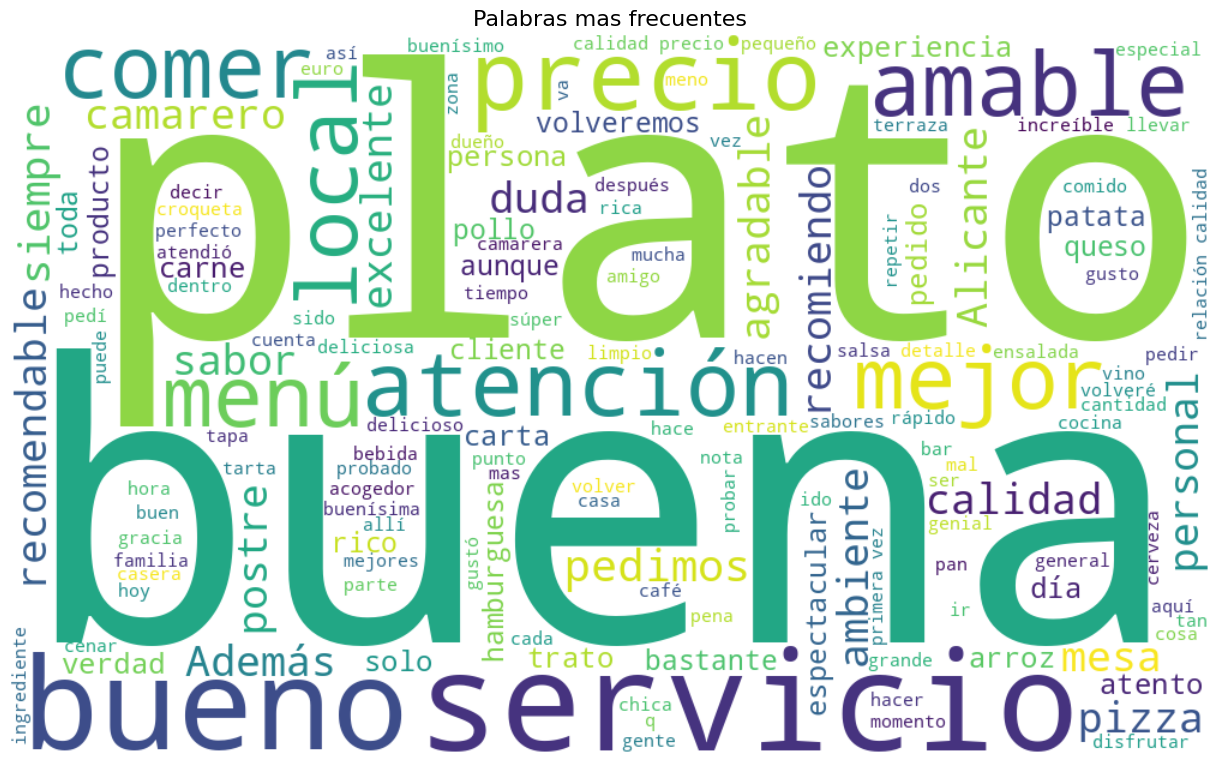

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

# Descargamos los diccionarios de NLTK (solo hace falta ejecutarlo una vez)
nltk.download('stopwords', quiet=True)

print("=== 4. NUBE DE PALABRAS MULTILINGÜE ===")

todas_las_resenas = " ".join(texto for texto in df_reviews['text'].dropna())

stop_es = set(stopwords.words('spanish'))
stop_en = set(stopwords.words('english'))
terminos_extra = {"restaurante", "sitio", "lugar", "comida", "food", "restaurant", "place", "si", "bien", "good"}

stopwords_multi = stop_es.union(stop_en).union(terminos_extra)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    stopwords=stopwords_multi,
    colormap='viridis',
    min_font_size=10,
    max_words=150
).generate(todas_las_resenas)

plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras mas frecuentes', fontsize=16)
plt.tight_layout(pad=0)
plt.show()

# Parte 2


# 7. Saneamiento Avanzado: Filtrado de Categorías
Eliminamos los establecimientos que no son restaurantes en sentido estricto. Google Places incluye en sus resultados locales como centros comerciales, gasolineras o supermercados que contaminan la muestra. Primero analizaremos la frecuencia real de categorías para decidir qué eliminar con criterio, y luego aplicaremos el filtro.

In [ ]:
print("=== FRECUENCIA DE CATEGORÍAS (antes del filtrado) ===\n")

df_exploded_raw = df_restaurantes.assign(
    tipo=df_restaurantes['types'].str.split(', ')
).explode('tipo')

etiquetas_genericas = ['point_of_interest', 'establishment', 'food', 'restaurant', 'store']
frecuencia = (
    df_exploded_raw[~df_exploded_raw['tipo'].isin(etiquetas_genericas)]
    ['tipo']
    .value_counts()
)

print(frecuencia.to_string())
print(f"\nTotal de categorías únicas: {len(frecuencia)}")

=== FRECUENCIA DE CATEGORÍAS (antes del filtrado) ===

tipo
bar                       689
meal_takeaway             294
cafe                      217
meal_delivery             132
bakery                    107
grocery_or_supermarket     64
supermarket                51
night_club                 18
lodging                    16
liquor_store               15
health                     11
shopping_mall               5
travel_agency               4
clothing_store              4
spa                         3
pharmacy                    3
gym                         2
movie_theater               2
florist                     2
art_gallery                 1
laundry                     1
casino                      1
tourist_attraction          1
parking                     1
park                        1
beauty_salon                1
home_goods_store            1
finance                     1
convenience_store           1

Total de categorías únicas: 29


In [ ]:
LISTA_NEGRA = [
    'shopping_mall',
    'gas_station',
    'grocery_or_supermarket',
    'convenience_store',
    'supermarket',
    'department_store',
    'drugstore',
    'pharmacy',
    'lodging',
    'tourist_attraction',
    'gym', 'laundry', 'florist', 'beauty_salon', 'casino',
    'movie_theater', 'art_gallery', 'clothing_store',
    'finance', 'home_goods_store', 'liquor_store'
]

patron_negra = '|'.join(LISTA_NEGRA)
filas_antes = len(df_restaurantes)

df_restaurantes = df_restaurantes[
    ~df_restaurantes['types'].str.contains(patron_negra, na=False)
]

filas_despues = len(df_restaurantes)
print(f"Registros antes del filtrado:  {filas_antes}")
print(f"Registros eliminados:          {filas_antes - filas_despues}")
print(f"Registros tras el filtrado:    {filas_despues}")
print(f"\nMuestra de lo que queda:")
display(df_restaurantes.sample(5)[['name', 'types', 'ciudad']])

ids_validos = set(df_restaurantes['place_id'])
filas_rev_antes = len(df_reviews)
df_reviews = df_reviews[df_reviews['place_id'].isin(ids_validos)]
print(f"\nReseñas eliminadas por sincronización: {filas_rev_antes - len(df_reviews)}")
print(f"Reseñas restantes: {len(df_reviews)}")

Registros antes del filtrado:  2922
Registros eliminados:          109
Registros tras el filtrado:    2813

Muestra de lo que queda:


,name,types,ciudad
946,takeawaycocinaperuana,"establishment, food, point_of_interest, restau...",Alicante
2895,Restaurante asiático GENKI,"establishment, food, point_of_interest, restau...",Elche
839,Barbacoa delicias,"establishment, food, point_of_interest, restau...",Alicante
1845,La Chacha Alicantina,"establishment, food, point_of_interest, restau...",Alicante
2477,Kebab sirine,"establishment, food, point_of_interest, restau...",Elche



Reseñas eliminadas por sincronización: 521
Reseñas restantes: 12614


# 8. Imputación: Revisión de Nulos
Revisamos el estado actual de los nulos tras el filtrado. Como se comentó, la decisión es no imputar price_level: dejaremos los valores ausentes como NaN y seremos explícitos en cada análisis sobre cuántos registros tienen dato disponible.

In [ ]:
print("=== ESTADO DE NULOS TRAS EL FILTRADO ===\n")

nulos = df_restaurantes.isnull().sum()
nulos_pct = (nulos / len(df_restaurantes) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
print(resumen_nulos[resumen_nulos['Nulos'] > 0])

# Revertimos la imputación de price_level de la Parte 1
df_rest_ali_raw = pd.read_csv(ruta_base + 'dataset_restaurantes_alicante.csv')
df_rest_elx_raw = pd.read_csv(ruta_base + 'dataset_restaurantes_elche.csv')
df_rest_ali_raw['ciudad'] = 'Alicante'
df_rest_elx_raw['ciudad'] = 'Elche'
df_precio_original = pd.concat([df_rest_ali_raw, df_rest_elx_raw])[['place_id', 'price_level']]

df_restaurantes = df_restaurantes.drop(columns=['price_level'])
df_restaurantes = df_restaurantes.merge(df_precio_original, on='place_id', how='left')

con_precio = df_restaurantes['price_level'].notna().sum()
sin_precio = df_restaurantes['price_level'].isna().sum()
print(f"\nRegistros CON price_level: {con_precio} ({con_precio/len(df_restaurantes)*100:.1f}%)")
print(f"Registros SIN price_level: {sin_precio} ({sin_precio/len(df_restaurantes)*100:.1f}%)")
print("\nLos análisis de precio se realizarán sobre los registros con dato disponible.")

=== ESTADO DE NULOS TRAS EL FILTRADO ===

        Nulos  % del total
rating    181          6.4

Registros CON price_level: 1277 (45.4%)
Registros SIN price_level: 1536 (54.6%)

Los análisis de precio se realizarán sobre los registros con dato disponible.


# 9. Desviación Estándar
La media del rating nos dice el nivel de calidad percibido, pero oculta si hay consenso o polarización entre los clientes. Una desviación estándar alta significa que el local genera opiniones muy divididas. Analizamos esto a nivel de ciudad y de categoría.

In [ ]:
import plotly.express as px

print("=== DESVIACIÓN ESTÁNDAR DEL RATING ===\n")

estadisticas = df_restaurantes.groupby('ciudad')['rating'].agg(
    media='mean',
    mediana='median',
    desviacion_std='std',
    total='count'
).round(3)

print("--- Por ciudad ---")
display(estadisticas)

df_exp_std = df_restaurantes.assign(
    tipo=df_restaurantes['types'].str.split(', ')
).explode('tipo')

etiquetas_genericas = ['point_of_interest', 'establishment', 'food', 'restaurant', 'store']
df_exp_std = df_exp_std[~df_exp_std['tipo'].isin(etiquetas_genericas)]

std_categoria = (
    df_exp_std.groupby('tipo')['rating']
    .agg(media='mean', std='std', n='count')
    .query('n >= 30')
    .sort_values('std', ascending=False)
    .round(3)
    .head(15)
)

print("\n--- Top 15 categorías más polarizadas (mayor std) ---")
display(std_categoria)

fig_std = px.bar(
    std_categoria.reset_index(),
    x='tipo',
    y='std',
    color='media',
    color_continuous_scale='RdYlGn',
    title='Polarización por Categoría (Desviación Estándar del Rating)',
    labels={'tipo': 'Categoría', 'std': 'Desviación Estándar', 'media': 'Rating Medio'}
)
fig_std.update_layout(xaxis_tickangle=-45, plot_bgcolor='white')
fig_std.show()

=== DESVIACIÓN ESTÁNDAR DEL RATING ===

--- Por ciudad ---


,media,mediana,desviacion_std,total
ciudad,,,,
Alicante,4.319,4.4,0.506,2022
Elche,4.283,4.4,0.515,610



--- Top 15 categorías más polarizadas (mayor std) ---


,media,std,n
tipo,,,
meal_takeaway,4.276,0.467,259
bar,4.319,0.431,661
meal_delivery,4.199,0.421,130
bakery,4.419,0.406,57
cafe,4.386,0.382,207


In [ ]:
# Necesita ejecutar categorización IA
std_categoria_ia = (
    df_restaurantes[df_restaurantes['categoria_ia'].notna()]
    .groupby('categoria_ia')['rating']
    .agg(media='mean', std='std', n='count')
    .query('n >= 10')
    .sort_values('std', ascending=False)
    .round(3)
)

print("--- Polarización por categoría IA ---")
display(std_categoria_ia)

fig_std_ia = px.bar(
    std_categoria_ia.reset_index(),
    x='categoria_ia',
    y='std',
    color='media',
    color_continuous_scale='RdYlGn',
    text='std',
    title='Polarización por Categoría Gastronómica (Desviación Estándar del Rating)',
    labels={
        'categoria_ia': 'Categoría',
        'std': 'Desviación Estándar',
        'media': 'Rating Medio'
    }
)
fig_std_ia.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_std_ia.update_layout(xaxis_tickangle=-45, plot_bgcolor='white')
fig_std_ia.show()

KeyError: 'categoria_ia'

# 10. Nube de Palabras de Descripciones Editoriales
A diferencia de la nube de reseñas, esta nube extrae el vocabulario de los resúmenes de cada local. Analizamos si el lenguaje de posicionamiento difiere entre Alicante y Elche.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

df_con_summary = df_restaurantes[df_restaurantes['summary'] != 'Sin datos']
print(f"Restaurantes con summary disponible: {len(df_con_summary)} "
      f"({len(df_con_summary)/len(df_restaurantes)*100:.1f}% del total)\n")

stop_es = set(stopwords.words('spanish'))
stop_en = set(stopwords.words('english'))
terminos_extra = {
    "restaurante", "sitio", "lugar", "comida", "food", "restaurant",
    "place", "si", "bien", "good", "ofrece", "cuenta", "también", "además"
}
stopwords_multi = stop_es.union(stop_en).union(terminos_extra)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Vocabulario Editorial por Ciudad (Summaries de Google)', fontsize=16)

for ax, ciudad in zip(axes, ['Alicante', 'Elche']):
    textos = df_con_summary[df_con_summary['ciudad'] == ciudad]['summary']
    corpus = " ".join(textos)

    if not corpus.strip():
        ax.set_title(f'{ciudad} — Sin datos suficientes')
        ax.axis('off')
        continue

    wc = WordCloud(
        width=800,
        height=500,
        background_color='white',
        stopwords=stopwords_multi,
        colormap='plasma',
        max_words=100
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{ciudad} ({len(textos)} descripciones)', fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 11. Categorización Automatizada con IA
Para enriquecer el dataset con categorías semánticas y útiles, conectamos Colab a la API de Gemini Flash. Por cada restaurante, construimos un contexto combinando su nombre, descripción editorial y las reseñas disponibles, y le pedimos al modelo que lo clasifique en una única categoría de una lista cerrada predefinida. El proceso incluye guardado progresivo cada 20 registros para poder reanudar en caso de interrupción, y manejo automático de los límites de la API.

In [ ]:
import os
import time
import pandas as pd
from tqdm import tqdm
from google.colab import userdata

try:
    from groq import Groq
except ImportError:
    !pip install -q groq
    from groq import Groq

print("=== INICIALIZANDO MODELO DE IA (Groq) ===")

try:
    client = Groq(api_key=userdata.get('GROQ_API'))
    print("Conexión con la API de Groq establecida correctamente.\n")
except Exception as e:
    print("Error: No se ha encontrado el secreto 'GROQ_API_KEY'")
    raise e

LISTA_CATEGORIAS = [
    "Arroces y Paella", "Tapas y Pinchos", "Mediterránea", "Italiana",
    "Japonesa y Sushi", "Asiática", "Árabe y Kebab", "Hamburguesería",
    "Pizzería", "Cafetería y Desayunos", "Marisquería y Pescados",
    "Carnes y Parrilla", "Comida Rápida", "Vegana y Vegetariana",
    "Mexicana", "Latinoamericana", "Otros"
]

PROMPT_SISTEMA = f"""
Eres un experto crítico gastronómico en la zona de Alicante y Elche.
Clasifica el restaurante en UNA SOLA categoría de esta lista exacta:
{", ".join(LISTA_CATEGORIAS)}

Instrucciones:
1. Responde ÚNICAMENTE con la categoría exacta. Ni una palabra más.
2. Prioriza el nombre y la descripción corporativa.
3. Si no encaja claramente en ninguna, responde 'Otros'.
"""

# Prueba rápida de conexión
print("Probando conexión")
try:
    test = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": "Responde solo con la palabra: hola"},
            {"role": "user", "content": "test"}
        ],
        max_tokens=10
    )
    print(f"Prueba exitosa. Respuesta del modelo: {test.choices[0].message.content.strip()}")
except Exception as e:
    print(f"Error en la prueba: {e}")
    raise e

print("\nLista de categorías cargada:")
for i, cat in enumerate(LISTA_CATEGORIAS, 1):
    print(f"  {i}. {cat}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.5 MB/s eta 0:00:00
=== INICIALIZANDO MODELO DE IA (Groq) ===
✅ Conexión con la API de Groq establecida correctamente.

🔍 Probando conexión...
✅ Prueba exitosa. Respuesta del modelo: ¡listo!

Lista de categorías cargada:
  1. Arroces y Paella
  2. Tapas y Pinchos
  3. Mediterránea
  4. Italiana
  5. Japonesa y Sushi
  6. Asiática
  7. Árabe y Kebab
  8. Hamburguesería
  9. Pizzería
  10. Cafetería y Desayunos
  11. Marisquería y Pescados
  12. Carnes y Parrilla
  13. Comida Rápida
  14. Vegana y Vegetariana
  15. Mexicana
  16. Latinoamericana
  17. Otros


In [ ]:
archivo_salida = '/content/drive/MyDrive/TFG/restaurantes_categorizados_ia.csv'
MAX_PETICIONES_DIA = 14000
procesados = []

if os.path.exists(archivo_salida):
    df_progreso = pd.read_csv(archivo_salida)
    # Eliminamos los Error API anteriores de Gemini para reprocesarlos
    df_progreso = df_progreso[df_progreso['categoria_ia'] != 'Error API']
    procesados = df_progreso['place_id'].tolist()
    # Sobreescribimos el CSV limpio sin los errores
    df_progreso.to_csv(archivo_salida, index=False)
    print(f"Guardado previo encontrado. Restaurantes ya categorizados: {len(procesados)}")
else:
    print("Iniciando categorización desde cero.")

df_pendientes = df_restaurantes[~df_restaurantes['place_id'].isin(procesados)].copy()
total_pendientes = len(df_pendientes)
print(f"Restaurantes pendientes: {total_pendientes}")
print(f"Límite diario Groq: {MAX_PETICIONES_DIA} peticiones\n")

nuevos_datos = []
contador_guardado = 0
contador_dia = 0

for index, row in tqdm(df_pendientes.iterrows(), total=total_pendientes, desc="Categorizando con Groq"):

    if contador_dia >= MAX_PETICIONES_DIA:
        print(f"\nLímite diario alcanzado ({contador_dia} peticiones).")
        break

    place_id = row['place_id']
    nombre = str(row['name'])
    desc = str(row['summary']) if row['summary'] != 'Sin datos' else ''

    reviews_local = df_reviews[df_reviews['place_id'] == place_id]['text'].dropna().tolist()
    textos_resenas = " | ".join(reviews_local)[:1000]

    contexto = f"Restaurante: {nombre}. Descripción oficial: {desc}. Comentarios de clientes: {textos_resenas}"

    categoria = None
    intentos = 0

    while categoria is None and intentos < 3:
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[
                    {"role": "system", "content": PROMPT_SISTEMA},
                    {"role": "user", "content": f"Datos a analizar:\n{contexto}"}
                ],
                max_tokens=20
            )
            resultado = response.choices[0].message.content.strip().replace(".", "")

            if resultado in LISTA_CATEGORIAS:
                categoria = resultado
            else:
                categoria = "Otros"

        except Exception as e:
            intentos += 1
            if "429" in str(e):
                print(f"\nLímite por minuto alcanzado. Esperando 60 segundos...")
                time.sleep(60)
            else:
                print(f"\nError inesperado en {nombre}: {e}")
                categoria = "Error API"

    if categoria is None:
        categoria = "Error API"

    nuevos_datos.append({'place_id': place_id, 'categoria_ia': categoria})
    contador_guardado += 1
    contador_dia += 1

    time.sleep(2)

    if contador_guardado % 50 == 0:
        df_temp = pd.DataFrame(nuevos_datos)
        df_temp.to_csv(
            archivo_salida,
            mode='a',
            header=not os.path.exists(archivo_salida),
            index=False
        )
        nuevos_datos = []
        print(f"\nGuardado parcial: {len(procesados) + contador_guardado} restaurantes procesados")

if nuevos_datos:
    df_temp = pd.DataFrame(nuevos_datos)
    df_temp.to_csv(
        archivo_salida,
        mode='a',
        header=not os.path.exists(archivo_salida),
        index=False
    )

print(f"\nProceso completad, total procesados hoy: {contador_dia}")
print(f"Pendientes restantes: {total_pendientes - contador_dia}")

🔄 Guardado previo encontrado. Restaurantes ya categorizados: 2923
Restaurantes pendientes: 0
Límite diario Groq: 14000 peticiones



Categorizando con Groq: 0it [00:00, ?it/s]


🎉 ¡Proceso completado! Total procesados hoy: 0
Pendientes restantes: 0


In [ ]:
print("=== CONSOLIDANDO RESULTADOS EN EL DATASET PRINCIPAL ===\n")

df_categorias = pd.read_csv(archivo_salida)

# En caso de duplicados por reanudaciones, nos quedamos con el último resultado
df_categorias = df_categorias.drop_duplicates(subset=['place_id'], keep='last')

# Mergeamos con el dataset principal
df_restaurantes = df_restaurantes.merge(df_categorias, on='place_id', how='left')

# Rellenamos los que no tuvieron datos suficientes
df_restaurantes['categoria_ia'] = df_restaurantes['categoria_ia'].fillna('Sin datos suficientes')

# Resumen de resultados
print(f"Restaurantes con categoría asignada: {df_restaurantes['categoria_ia'].notna().sum()}")
print(f"\nDistribución de categorías:")
display(
    df_restaurantes['categoria_ia']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Categoría', 'categoria_ia': 'Total'})
)

# Comprobación de errores
errores = df_restaurantes[df_restaurantes['categoria_ia'] == 'Error API']
if len(errores) > 0:
    print(f"\nRegistros con error de API: {len(errores)}. Puedes relanzar la celda 11B para reintentarlos.")
else:
    print("\nSin errores de API. Dataset listo para el análisis.")

=== CONSOLIDANDO RESULTADOS EN EL DATASET PRINCIPAL ===

Restaurantes con categoría asignada: 2813

Distribución de categorías:


,Total,count
0,Tapas y Pinchos,335
1,Carnes y Parrilla,329
2,Cafetería y Desayunos,307
3,Arroces y Paella,306
4,Árabe y Kebab,207
5,Hamburguesería,187
6,Mediterránea,171
7,Comida Rápida,152
8,Marisquería y Pescados,148
9,Otros,127



✅ Sin errores de API. Dataset listo para el análisis.


# Parte 3 — Análisis de Datos
En esta sección se aplican técnicas de análisis estadístico, aprendizaje automático y procesamiento de lenguaje natural sobre el dataset limpio y enriquecido. El objetivo es extraer conocimiento real del sector restaurador en Alicante y Elche, respondiendo preguntas concretas sobre la distribución de la oferta gastronómica, las correlaciones entre variables, los perfiles de establecimiento y los patrones en la opinión de los clientes.

# 12. Análisis Comparativo por Categoría Gastronómica
Con la columna categoria_ia generada en la fase anterior, podemos analizar por primera vez la oferta gastronómica real de ambas ciudades con etiquetas semánticas limpias. Este bloque responde tres preguntas: cómo se distribuyen las categorías en cada ciudad, si el rating medio difiere entre categorías y ciudades, y si el precio medio sigue el mismo patrón.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Filtramos registros sin categoría válida
df_cat = df_restaurantes[df_restaurantes['categoria_ia'] != 'Sin datos suficientes'].copy()

# Conteo por categoría y ciudad
dist_cat = (
    df_cat.groupby(['ciudad', 'categoria_ia'])
    .size()
    .reset_index(name='total')
)

# Porcentaje dentro de cada ciudad
dist_cat['pct'] = dist_cat.groupby('ciudad')['total'].transform(lambda x: (x / x.sum() * 100).round(1))

# Ordenamos por total global para que las barras tengan sentido
orden_categorias = (
    dist_cat.groupby('categoria_ia')['total']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

fig = px.bar(
    dist_cat,
    x='categoria_ia',
    y='pct',
    color='ciudad',
    barmode='group',
    category_orders={'categoria_ia': orden_categorias},
    title='Distribución de Categorías Gastronómicas por Ciudad (%)',
    labels={'categoria_ia': 'Categoría', 'pct': '% sobre el total de la ciudad', 'ciudad': 'Ciudad'},
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

print("\nTabla de distribución completa:")
display(dist_cat.pivot_table(index='categoria_ia', columns='ciudad', values='pct').round(1))


Tabla de distribución completa:


ciudad,Alicante,Elche
categoria_ia,,
Arroces y Paella,11.2,9.7
Asiática,3.4,2.3
Cafetería y Desayunos,11.2,10.0
Carnes y Parrilla,11.0,14.1
Comida Rápida,5.5,5.1
Hamburguesería,6.7,6.5
Italiana,2.5,2.3
Japonesa y Sushi,4.2,4.2
Latinoamericana,0.5,0.5


In [ ]:
# Filtramos NaN de rating
df_rating_cat = df_cat[df_cat['rating'].notna()].copy()

rating_cat = (
    df_rating_cat.groupby(['ciudad', 'categoria_ia'])['rating']
    .agg(media='mean', n='count')
    .reset_index()
)

# Solo categorías con muestra suficiente en ambas ciudades
categorias_validas = (
    rating_cat[rating_cat['n'] >= 10]
    .groupby('categoria_ia')['ciudad']
    .count()
)
categorias_validas = categorias_validas[categorias_validas == 2].index.tolist()

rating_cat = rating_cat[rating_cat['categoria_ia'].isin(categorias_validas)]

# Ordenamos por media global descendente
orden_rating = (
    rating_cat.groupby('categoria_ia')['media']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig2 = px.bar(
    rating_cat,
    x='categoria_ia',
    y='media',
    color='ciudad',
    barmode='group',
    text='media',
    category_orders={'categoria_ia': orden_rating},
    title='Rating Medio por Categoría Gastronómica y Ciudad',
    labels={'categoria_ia': 'Categoría', 'media': 'Rating Medio', 'ciudad': 'Ciudad'},
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'},
    range_y=[3.5, 5.0]
)

fig2.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig2.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig2.show()

In [ ]:
# Filtramos NaN de price_level
df_precio_cat = df_cat[df_cat['price_level'].notna()].copy()

precio_cat = (
    df_precio_cat.groupby(['ciudad', 'categoria_ia'])['price_level']
    .agg(media='mean', n='count')
    .reset_index()
)

precio_cat = precio_cat[precio_cat['categoria_ia'].isin(categorias_validas)]

orden_precio = (
    precio_cat.groupby('categoria_ia')['media']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Mapa de niveles de precio para el eje
etiquetas_precio = {1: 'Barato', 2: 'Moderado', 3: 'Caro', 4: 'Muy caro'}

fig3 = px.bar(
    precio_cat,
    x='categoria_ia',
    y='media',
    color='ciudad',
    barmode='group',
    text='media',
    category_orders={'categoria_ia': orden_precio},
    title='Nivel de Precio Medio por Categoría Gastronómica y Ciudad',
    labels={'categoria_ia': 'Categoría', 'media': 'Price Level Medio', 'ciudad': 'Ciudad'},
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig3.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig3.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    yaxis=dict(
        tickvals=[1, 2, 3, 4],
        ticktext=['1 - Barato', '2 - Moderado', '3 - Caro', '4 - Muy caro']
    )
)
fig3.show()

print("\nResumen ejecutivo del bloque:")
print(f"Categoría más frecuente en Alicante: {dist_cat[dist_cat['ciudad']=='Alicante'].nlargest(1, 'total')['categoria_ia'].values[0]}")
print(f"Categoría más frecuente en Elche:    {dist_cat[dist_cat['ciudad']=='Elche'].nlargest(1, 'total')['categoria_ia'].values[0]}")
print(f"Categoría mejor valorada (media):    {rating_cat.groupby('categoria_ia')['media'].mean().idxmax()}")
print(f"Categoría más cara (media):          {precio_cat.groupby('categoria_ia')['media'].mean().idxmax()}")


Resumen ejecutivo del bloque:
Categoría más frecuente en Alicante: Arroces y Paella
Categoría más frecuente en Elche:    Tapas y Pinchos
Categoría mejor valorada (media):    Vegana y Vegetariana
Categoría más cara (media):          Mediterránea


# 13. Análisis de Correlaciones
Una vez conocida la distribución categórica de la oferta, analizamos las relaciones entre las variables numéricas del dataset. El objetivo es determinar si existe una asociación estadísticamente relevante entre el precio, el rating y el volumen de reseñas, y si esa relación difiere entre ciudades. Para ello combinaremos un heatmap de correlaciones global con scatter plots específicos para las relaciones más relevantes.

In [ ]:
import plotly.figure_factory as ff
import numpy as np

# Seleccionamos solo registros con todas las variables numéricas completas
df_corr = df_restaurantes[['rating', 'price_level', 'user_ratings_total']].dropna()

# Calculamos correlaciones de Pearson y Spearman
corr_pearson = df_corr.corr(method='pearson').round(3)
corr_spearman = df_corr.corr(method='spearman').round(3)

print("=== CORRELACIONES DE PEARSON ===")
display(corr_pearson)
print("\n=== CORRELACIONES DE SPEARMAN ===")
display(corr_spearman)

# Heatmap de Pearson
fig = ff.create_annotated_heatmap(
    z=corr_pearson.values,
    x=corr_pearson.columns.tolist(),
    y=corr_pearson.index.tolist(),
    annotation_text=corr_pearson.values.round(2).astype(str),
    colorscale='RdBu',
    zmid=0,
    showscale=True
)

fig.update_layout(
    title='Heatmap de Correlaciones de Pearson (Variables Numéricas)',
    width=600,
    height=500
)
fig.show()

# Heatmap de Spearman
fig2 = ff.create_annotated_heatmap(
    z=corr_spearman.values,
    x=corr_spearman.columns.tolist(),
    y=corr_spearman.index.tolist(),
    annotation_text=corr_spearman.values.round(2).astype(str),
    colorscale='RdBu',
    zmid=0,
    showscale=True
)

fig2.update_layout(
    title='Heatmap de Correlaciones de Spearman (Variables Numéricas)',
    width=600,
    height=500
)
fig2.show()

=== CORRELACIONES DE PEARSON ===


,rating,price_level,user_ratings_total
rating,1.000,0.13,0.003
price_level,0.130,1.00,0.320
user_ratings_total,0.003,0.32,1.000



=== CORRELACIONES DE SPEARMAN ===


,rating,price_level,user_ratings_total
rating,1.000,0.138,-0.022
price_level,0.138,1.000,0.391
user_ratings_total,-0.022,0.391,1.000


In [ ]:
import plotly.express as px
df_scatter = df_restaurantes[
    df_restaurantes['rating'].notna() &
    df_restaurantes['price_level'].notna()
].copy()

# Mapeamos price_level a etiqueta legible
df_scatter['precio_label'] = df_scatter['price_level'].map({
    1.0: '1 - Barato',
    2.0: '2 - Moderado',
    3.0: '3 - Caro',
    4.0: '4 - Muy caro'
})

# Boxplot de rating por nivel de precio y ciudad
fig3 = px.box(
    df_scatter,
    x='precio_label',
    y='rating',
    color='ciudad',
    title='Distribución del Rating por Nivel de Precio y Ciudad',
    labels={
        'precio_label': 'Nivel de Precio',
        'rating': 'Rating',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'},
    category_orders={'precio_label': ['1 - Barato', '2 - Moderado', '3 - Caro', '4 - Muy caro']}
)

fig3.update_layout(plot_bgcolor='white')
fig3.show()

# Media de rating por nivel de precio
print("\nMedia de rating por nivel de precio:")
display(
    df_scatter.groupby(['precio_label', 'ciudad'])['rating']
    .mean()
    .round(3)
    .unstack()
)


Media de rating por nivel de precio:


ciudad,Alicante,Elche
precio_label,,
1 - Barato,4.225,4.200
2 - Moderado,4.309,4.344
3 - Caro,4.379,4.600
4 - Muy caro,4.400,3.500


In [ ]:
# Aplicamos log al volumen para comprimir la escala (hay outliers con miles de reseñas)
from scipy import stats

df_vol = df_restaurantes[
    df_restaurantes['rating'].notna() &
    (df_restaurantes['user_ratings_total'] > 0)
].copy()

df_vol['log_resenas'] = np.log10(df_vol['user_ratings_total'])

fig4 = px.scatter(
    df_vol,
    x='log_resenas',
    y='rating',
    color='ciudad',
    opacity=0.4,
    trendline='ols',
    title='Relación entre Volumen de Reseñas (log) y Rating por Ciudad',
    labels={
        'log_resenas': 'Log10 del número de reseñas',
        'rating': 'Rating',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig4.update_layout(plot_bgcolor='white')
fig4.show()

# Correlacion especifica entre volumen y rating por ciudad
print("\nCorrelación Spearman entre volumen de reseñas y rating por ciudad:")
for ciudad in ['Alicante', 'Elche']:
    subset = df_vol[df_vol['ciudad'] == ciudad]
    corr, pval = stats.spearmanr(subset['user_ratings_total'], subset['rating'])
    print(f"  {ciudad}: r = {corr:.3f}, p-valor = {pval:.4f} {'significativa' if pval < 0.05 else 'no significativa'}")


Correlación Spearman entre volumen de reseñas y rating por ciudad:
  Alicante: r = -0.128, p-valor = 0.0000 ✅ significativa
  Elche: r = -0.102, p-valor = 0.0114 ✅ significativa


In [ ]:
df_corr_cat = df_restaurantes[
    df_restaurantes['rating'].notna() &
    df_restaurantes['price_level'].notna() &
    (df_restaurantes['categoria_ia'] != 'Sin datos suficientes')
].copy()

corr_por_categoria = (
    df_corr_cat.groupby('categoria_ia', group_keys=False)
    .apply(lambda x: pd.Series({
        'correlacion_precio_rating': x['rating'].corr(x['price_level'], method='spearman'),
        'n': len(x)
    }))
    .query('n >= 15')
    .drop(columns='n')
    .round(3)
    .sort_values('correlacion_precio_rating', ascending=False)
    .reset_index()
)

fig5 = px.bar(
    corr_por_categoria,
    x='categoria_ia',
    y='correlacion_precio_rating',
    color='correlacion_precio_rating',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title='Correlación Spearman entre Precio y Rating por Categoría Gastronómica',
    labels={
        'categoria_ia': 'Categoría',
        'correlacion_precio_rating': 'Correlación (Spearman)'
    }
)

fig5.update_layout(xaxis_tickangle=-45, plot_bgcolor='white')
fig5.add_hline(y=0, line_dash='dash', line_color='gray')
fig5.show()

print("\nInterpretación:")
print("  Valores > 0: a mayor precio, mejor rating en esa categoría")
print("  Valores < 0: a mayor precio, peor rating en esa categoría")
print("  Valores ≈ 0: no hay relación clara entre precio y rating")

/tmp/ipykernel_575/3560446081.py:9: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Interpretación:
  Valores > 0: a mayor precio, mejor rating en esa categoría
  Valores < 0: a mayor precio, peor rating en esa categoría
  Valores ≈ 0: no hay relación clara entre precio y rating


# 14. Ranking de Restaurantes
Un ranking basado únicamente en la nota media no es estadísticamente justo: un restaurante con 3 reseñas y un 5.0 no es comparable con uno con 800 reseñas y un 4.6. Para resolver esto aplicamos la fórmula de Bayesian Average, que pondera la nota de cada restaurante hacia la media global cuando el volumen de reseñas es bajo. Es la misma fórmula que usa IMDb para sus rankings de películas. A más reseñas, más peso tiene la nota propia del restaurante. A menos reseñas, más se acerca a la media global.
La fórmula es: (v × R + m × C) / (v + m), donde v es el número de reseñas del restaurante, R es su nota media, m es el mínimo de reseñas requerido (usaremos el percentil 25) y C es la media global de ratings.

In [ ]:
# Filtramos restaurantes con rating válido
df_rank = df_restaurantes[
    df_restaurantes['rating'].notna() &
    (df_restaurantes['user_ratings_total'] > 0) &
    (df_restaurantes['categoria_ia'] != 'Sin datos suficientes')
].copy()

# Parámetros de la fórmula
C = df_rank['rating'].mean()                          # Media global
m = df_rank['user_ratings_total'].quantile(0.25)      # Percentil 25 como mínimo

print(f"Media global de rating (C): {C:.3f}")
print(f"Mínimo de reseñas requerido (m): {m:.0f}")

# Aplicamos la fórmula Bayesian Average
df_rank['bayesian_rating'] = (
    (df_rank['user_ratings_total'] * df_rank['rating'] + m * C) /
    (df_rank['user_ratings_total'] + m)
).round(3)

# Top 20 global
top20_global = (
    df_rank.nlargest(20, 'bayesian_rating')
    [['name', 'ciudad', 'categoria_ia', 'rating', 'user_ratings_total', 'bayesian_rating']]
    .reset_index(drop=True)
)
top20_global.index += 1

print(f"\n=== TOP 20 RESTAURANTES (Bayesian Rating) ===")
display(top20_global)

Media global de rating (C): 4.310
Mínimo de reseñas requerido (m): 69

=== TOP 20 RESTAURANTES (Bayesian Rating) ===


,name,ciudad,categoria_ia,rating,user_ratings_total,bayesian_rating
1,Donde Nakiss Brunch & Tapas,Alicante,Vegana y Vegetariana,5.0,621.0,4.931
2,Wacha Bar,Alicante,Mexicana,5.0,487.0,4.914
3,Banaras cocina vegetal creativa: restaurante v...,Alicante,Vegana y Vegetariana,5.0,423.0,4.903
4,Shawarma El Camello | Comida Jordana en Alicante,Alicante,Árabe y Kebab,5.0,402.0,4.899
5,La Mole | Restaurante Italiano Alicante,Alicante,Italiana,5.0,370.0,4.892
6,Bar Vino y Más Elx,Elche,Tapas y Pinchos,4.9,5303.0,4.892
7,La Folie Burgers & Tatuaje,Alicante,Carnes y Parrilla,4.9,2768.0,4.886
8,Cafeteria Tres Texturas - Brunch & Coffee,Alicante,Cafetería y Desayunos,4.9,2223.0,4.882
9,EatMyTrip Specialty Coffee & Brunch Alicante,Alicante,Cafetería y Desayunos,4.9,1693.0,4.877
10,Restaurant LÀ MÈIzi,Alicante,Japonesa y Sushi,5.0,318.0,4.877


In [ ]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Top 15 — Alicante', 'Top 15 — Elche')
)

for i, ciudad in enumerate(['Alicante', 'Elche'], 1):
    top_ciudad = (
        df_rank[df_rank['ciudad'] == ciudad]
        .nlargest(15, 'bayesian_rating')
        [['name', 'bayesian_rating', 'categoria_ia']]
        .reset_index(drop=True)
    )

    fig.add_trace(
        go.Bar(
            x=top_ciudad['bayesian_rating'],
            y=top_ciudad['name'],
            orientation='h',
            name=ciudad,
            text=top_ciudad['bayesian_rating'].round(3),
            textposition='outside',
            hovertext=top_ciudad['categoria_ia'],
            marker_color='#1f77b4' if ciudad == 'Alicante' else '#ff7f0e'
        ),
        row=1, col=i
    )

fig.update_layout(
    title='Top 15 Restaurantes por Ciudad (Bayesian Rating)',
    height=600,
    showlegend=False,
    plot_bgcolor='white'
)
fig.update_xaxes(range=[3.5, 5.2])
fig.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Top 15 — Alicante', 'Top 15 — Elche'),
    horizontal_spacing=0.15
)

for i, ciudad in enumerate(['Alicante', 'Elche'], 1):
    top_ciudad = (
        df_rank[df_rank['ciudad'] == ciudad]
        .nlargest(15, 'bayesian_rating')
        [['name', 'bayesian_rating', 'categoria_ia']]
        .reset_index(drop=True)
        .sort_values('bayesian_rating', ascending=True)
    )

    # Acortamos nombres largos
    top_ciudad['name_corto'] = top_ciudad['name'].apply(
        lambda x: x[:30] + '...' if len(x) > 30 else x
    )

    color = '#1f77b4' if ciudad == 'Alicante' else '#ff7f0e'

    fig.add_trace(
        go.Bar(
            x=top_ciudad['bayesian_rating'],
            y=top_ciudad['name_corto'],
            orientation='h',
            text=top_ciudad['bayesian_rating'].round(3),
            textposition='outside',
            hovertext=top_ciudad['categoria_ia'],
            hoverinfo='text+x',
            marker_color=color,
            name=ciudad
        ),
        row=1, col=i
    )

fig.update_layout(
    title='Top 15 Restaurantes por Ciudad (Bayesian Rating)',
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_xaxes(range=[4.5, 5.1], row=1, col=1)
fig.update_xaxes(range=[4.5, 5.1], row=1, col=2)
fig.update_xaxes(title_text='Bayesian Rating', row=1, col=1)
fig.update_xaxes(title_text='Bayesian Rating', row=1, col=2)

fig.show()

In [ ]:
# Calculamos el top 5 de cada categoría
tops_categoria = []

for categoria in sorted(df_rank['categoria_ia'].unique()):
    subset = df_rank[df_rank['categoria_ia'] == categoria]
    if len(subset) < 5:
        continue
    top5 = (
        subset.nlargest(5, 'bayesian_rating')
        [['name', 'ciudad', 'categoria_ia', 'rating', 'user_ratings_total', 'bayesian_rating']]
    )
    tops_categoria.append(top5)

df_tops = pd.concat(tops_categoria).reset_index(drop=True)

# Visualización: mejor restaurante de cada categoría
mejor_por_cat = (
    df_rank.groupby('categoria_ia')
    .apply(lambda x: x.nlargest(1, 'bayesian_rating'), include_groups=False)
    .reset_index(level=0)
    .reset_index(drop=True)
    [['categoria_ia', 'name', 'ciudad', 'rating', 'user_ratings_total', 'bayesian_rating']]
    .sort_values('bayesian_rating', ascending=True)
)

fig2 = px.bar(
    mejor_por_cat,
    x='bayesian_rating',
    y='categoria_ia',
    orientation='h',
    color='ciudad',
    text='name',
    title='Mejor Restaurante por Categoría Gastronómica (Bayesian Rating)',
    labels={
        'bayesian_rating': 'Bayesian Rating',
        'categoria_ia': 'Categoría',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig2.update_traces(textposition='inside', insidetextanchor='start')
fig2.update_layout(
    plot_bgcolor='white',
    xaxis=dict(range=[3.5, 5.2]),
    height=600
)
fig2.show()

print("\n=== TOP 5 POR CATEGORÍA ===")
for categoria in sorted(df_rank['categoria_ia'].unique()):
    subset = df_tops[df_tops['categoria_ia'] == categoria]
    if len(subset) == 0:
        continue
    print(f"\n--- {categoria} ---")
    display(subset[['name', 'ciudad', 'rating', 'user_ratings_total', 'bayesian_rating']].reset_index(drop=True))


=== TOP 5 POR CATEGORÍA ===

--- Arroces y Paella ---


,name,ciudad,rating,user_ratings_total,bayesian_rating
0,Restaurante K la iaia Arrocería.,Alicante,4.8,430.0,4.732
1,Senyoret. Arrocería,Alicante,4.8,417.0,4.730
2,La Bona Gastrobar,Alicante,4.8,412.0,4.730
3,Restaurante El Meu Foc,Alicante,4.9,168.0,4.728
4,LA LLUM DEL FOC,Alicante,4.9,144.0,4.709



--- Asiática ---


,name,ciudad,rating,user_ratings_total,bayesian_rating
0,Mantra Restaurante Hindu,Elche,4.9,686.0,4.846
1,NOODLES,Alicante,4.8,484.0,4.739
2,ZHAN Asian Fusion,Alicante,4.8,317.0,4.712
3,Mantra 2 Restaurante Hindú,Elche,4.8,292.0,4.706
4,El Rollito | Thai Food,Alicante,4.8,268.0,4.700



--- Cafetería y Desayunos ---


...

,name,ciudad,rating,user_ratings_total,bayesian_rating
0,Bar Vino y Más Elx,Elche,4.9,5303.0,4.892
1,NOMAD Alicante,Alicante,4.9,746.0,4.850
2,Teatro 18,Alicante,4.9,520.0,4.831
3,INSENSATO. Vermú y anchoas.,Alicante,4.9,365.0,4.806
4,Paquita's Bar | Bar en Elche,Elche,4.9,363.0,4.806



--- Vegana y Vegetariana ---


,name,ciudad,rating,user_ratings_total,bayesian_rating
0,Donde Nakiss Brunch & Tapas,Alicante,5.0,621.0,4.931
1,Banaras cocina vegetal creativa: restaurante v...,Alicante,5.0,423.0,4.903
2,Las Muns,Alicante,4.9,1208.0,4.868
3,Sabolé (Sede Playa de San Juan),Alicante,4.9,998.0,4.862
4,AMAZONIA ACAI ALICANTE,Alicante,4.9,751.0,4.850



--- Árabe y Kebab ---


,name,ciudad,rating,user_ratings_total,bayesian_rating
0,Shawarma El Camello | Comida Jordana en Alicante,Alicante,5.0,402.0,4.899
1,LasTricato,Elche,5.0,301.0,4.871
2,Daro Kebab,Alicante,4.9,862.0,4.856
3,Foodie fiesta,Alicante,4.9,229.0,4.763
4,Tetería Jardín Najima,Alicante,4.8,666.0,4.754


# 15. Análisis de Sentimiento
Las reseñas de los clientes contienen información cualitativa que el rating numérico no captura completamente. Un cliente puede poner 3 estrellas con un texto muy positivo porque considera que el precio no justifica más nota, o puede poner 5 estrellas con un texto neutro. El análisis de sentimiento nos permite extraer la polaridad emocional del texto de cada reseña de forma automática y compararla con la nota numérica, detectando inconsistencias y patrones por ciudad y categoría gastronómica.
Usaremos VADER para las reseñas en inglés, que funciona especialmente bien con texto coloquial y corto, y TextBlob con el corpus en español para las reseñas en castellano. Dado que no tenemos el idioma etiquetado, detectaremos el idioma automáticamente con la librería langdetect.

In [ ]:
!pip install pysentimiento -q
from google.colab import drive
import os
import pandas as pd
from tqdm import tqdm
from pysentimiento import create_analyzer

drive.mount('/content/drive')

ruta_guardado = '/content/drive/MyDrive/TFG/dataset_reviews_sentimiento.csv'

print("Cargando modelo de análisis de sentimiento para español...")
analyzer = create_analyzer(task="sentiment", lang="es")
print("Modelo cargado correctamente")

# Función de análisis
def analizar_sentimiento(texto):
    try:
        resultado = analyzer.predict(str(texto)[:512])  # Límite de tokens
        return pd.Series({
            'sentimiento_label': resultado.output,
            'prob_positivo': resultado.probas.get('POS', 0),
            'prob_negativo': resultado.probas.get('NEG', 0),
            'prob_neutro': resultado.probas.get('NEU', 0)
        })
    except Exception as e:
        return pd.Series({
            'sentimiento_label': 'NEU',
            'prob_positivo': 0.0,
            'prob_negativo': 0.0,
            'prob_neutro': 1.0
        })

# 3. Lógica de Reanudación (Checkpoint)
if os.path.exists(ruta_guardado):
    print("Encontrado archivo de progreso anterior. Cargando desde Drive...")
    df_rev_nlp = pd.read_csv(ruta_guardado)
else:
    print("Creando nuevo archivo de análisis...")
    # Preparamos el dataset desde cero
    df_rev_nlp = df_reviews[df_reviews['text'].notna()].copy()
    df_rev_nlp = df_rev_nlp[df_rev_nlp['text'].str.strip() != ''].copy()

    # Creamos las columnas vacías
    df_rev_nlp['sentimiento_label'] = None
    df_rev_nlp['prob_positivo'] = None
    df_rev_nlp['prob_negativo'] = None
    df_rev_nlp['prob_neutro'] = None

# Identificamos cuáles faltan por analizar (las que tienen 'sentimiento_label' nulo)
pendientes_idx = df_rev_nlp[df_rev_nlp['sentimiento_label'].isna()].index
print(f"Reseñas totales: {len(df_rev_nlp)} | Faltan por analizar: {len(pendientes_idx)}")

# 4. Bucle de Procesamiento y Guardado
if len(pendientes_idx) > 0:
    print("\nAnalizando sentimiento con pysentimiento...")
    batch_size = 100

    for i in tqdm(range(0, len(pendientes_idx), batch_size)):
        # Índices del lote actual
        lote_idx = pendientes_idx[i:i+batch_size]

        # Aplicamos la predicción
        resultados = df_rev_nlp.loc[lote_idx, 'text'].apply(analizar_sentimiento)

        # Insertamos los resultados en el dataframe principal
        df_rev_nlp.loc[lote_idx, ['sentimiento_label', 'prob_positivo', 'prob_negativo', 'prob_neutro']] = resultados[['sentimiento_label', 'prob_positivo', 'prob_negativo', 'prob_neutro']].values

        # GUARDADO EN DRIVE CADA BATCH (Copia de seguridad)
        df_rev_nlp.to_csv(ruta_guardado, index=False)

# 5. Cálculo del score final (Se ejecuta cuando todo ha terminado)
df_rev_nlp['sentimiento_score'] = (
    df_rev_nlp['prob_positivo'] - df_rev_nlp['prob_negativo']
)
# Guardado definitivo con el score calculado
df_rev_nlp.to_csv(ruta_guardado, index=False)

print("\nAnálisis completado y guardado de forma segura en Drive")
print(f"\nDistribución global de sentimiento:")
display(df_rev_nlp['sentimiento_label'].value_counts())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.7 MB/s eta 0:00:00


KeyboardInterrupt: 

In [ ]:

if 'sentimiento_label' not in df_rev_nlp.columns:
    df_rev_nlp = pd.read_csv(ruta_base + 'sentimiento_resenas.csv')
    print(f"Cargado desde Drive: {len(df_rev_nlp)} reseñas")


df_rev_nlp['sentimiento_score'] = (
    df_rev_nlp['prob_positivo'] - df_rev_nlp['prob_negativo']
)


df_rev_nlp['sentimiento'] = df_rev_nlp['sentimiento_score']


df_rev_nlp['sentimiento_cat'] = df_rev_nlp['sentimiento_label'].map({
    'POS': 'Positivo',
    'NEG': 'Negativo',
    'NEU': 'Neutro'
})

print("Distribución global:")
display(df_rev_nlp['sentimiento_cat'].value_counts())

print("\nDistribución por ciudad:")
display(pd.crosstab(df_rev_nlp['ciudad'], df_rev_nlp['sentimiento_cat']))

In [ ]:
# Agrupamos por rating numérico y calculamos el sentimiento medio
df_rev_valido = df_rev_nlp[df_rev_nlp['rating'].notna()].copy()

sent_vs_rating = (
    df_rev_valido.groupby('rating')['sentimiento']
    .agg(media='mean', n='count')
    .round(3)
    .reset_index()
)

print("Sentimiento medio por rating numérico:")
display(sent_vs_rating)

fig = px.bar(
    sent_vs_rating,
    x='rating',
    y='media',
    color='media',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    text='media',
    title='Sentimiento Medio del Texto por Rating Numérico',
    labels={'rating': 'Rating (1-5)', 'media': 'Sentimiento Medio (-1 a +1)'}
)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(plot_bgcolor='white', showlegend=False)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()

# Detectamos inconsistencias: reseñas donde el sentimiento contradice el rating
df_rev_valido['inconsistente'] = (
    ((df_rev_valido['rating'] >= 4) & (df_rev_valido['sentimiento'] < -0.05)) |
    ((df_rev_valido['rating'] <= 2) & (df_rev_valido['sentimiento'] > 0.05))
)

n_inconsistentes = df_rev_valido['inconsistente'].sum()
pct_inconsistentes = n_inconsistentes / len(df_rev_valido) * 100

print(f"\nReseñas inconsistentes (texto contradice la nota): {n_inconsistentes} ({pct_inconsistentes:.1f}%)")
print("\nEjemplos de inconsistencias:")
display(
    df_rev_valido[df_rev_valido['inconsistente']]
    [['author_name', 'rating', 'sentimiento', 'text']]
    .head(5)
)

Sentimiento medio por rating numérico:


,rating,media,n
0,1,-0.864,1569
1,2,-0.647,385
2,3,-0.020,591
3,4,0.753,1420
4,5,0.933,8447



Reseñas inconsistentes (texto contradice la nota): 269 (2.2%)

Ejemplos de inconsistencias:


,author_name,rating,sentimiento,text
59,Pedro Muñoz Enriquez,4,-0.496715,Todo bien pero tenéis que cambiar el nombre de...
60,MEDE,4,-0.652642,"Restaurante chino tradicional,el de toda la vi..."
139,Roberto López Ortiz,2,0.727255,Fui a cenar con mi mujer y la verdad los preci...
142,Suny Marco,4,-0.888833,Fuimos a comer el menú de Mutxamel de platos d...
177,Domingo,4,-0.112972,El dia que nosotros acudimos la comida estaba ...


In [ ]:
# Mergeamos las reseñas con la categoría del restaurante
df_rev_cat = df_rev_nlp.merge(
    df_restaurantes[['place_id', 'categoria_ia', 'ciudad']],
    on=['place_id', 'ciudad'],
    how='left'
)

df_rev_cat = df_rev_cat[df_rev_cat['categoria_ia'] != 'Sin datos suficientes']

# Sentimiento medio por categoría y ciudad
sent_cat = (
    df_rev_cat.groupby(['ciudad', 'categoria_ia'])['sentimiento']
    .agg(media='mean', n='count')
    .query('n >= 10')
    .round(3)
    .reset_index()
)

orden = (
    sent_cat.groupby('categoria_ia')['media']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig2 = px.bar(
    sent_cat,
    x='categoria_ia',
    y='media',
    color='ciudad',
    barmode='group',
    category_orders={'categoria_ia': orden},
    title='Sentimiento Medio de las Reseñas por Categoría y Ciudad',
    labels={
        'categoria_ia': 'Categoría',
        'media': 'Sentimiento Medio (-1 a +1)',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig2.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig2.add_hline(y=0, line_dash='dash', line_color='gray')
fig2.show()

# Categorías con mayor y menor sentimiento global
print("\nCategorías con mejor sentimiento medio:")
display(sent_cat.groupby('categoria_ia')['media'].mean().nlargest(5).round(3))

print("\nCategorías con peor sentimiento medio:")
display(sent_cat.groupby('categoria_ia')['media'].mean().nsmallest(5).round(3))


Categorías con mejor sentimiento medio:


,media
categoria_ia,
Vegana y Vegetariana,0.794
Latinoamericana,0.778
Mexicana,0.748
Japonesa y Sushi,0.728
Italiana,0.724



Categorías con peor sentimiento medio:


,media
categoria_ia,
Comida Rápida,0.170
Árabe y Kebab,0.304
Otros,0.488
Asiática,0.504
Hamburguesería,0.514


# 16. Clustering de Restaurantes con K-Means
Hasta ahora hemos analizado los restaurantes usando variables por separado. El clustering nos permite agruparlos simultáneamente por todas sus características numéricas para descubrir si existen perfiles naturales de establecimiento que no son evidentes a simple vista. Por ejemplo, podría emerger un grupo de locales con precio alto, nota alta y pocas reseñas (restaurantes de nicho), otro con precio bajo, nota media y muchísimas reseñas (cadenas muy visitadas), etc.
El algoritmo K-Means agrupa los restaurantes minimizando la distancia entre cada punto y el centro de su cluster. Antes de aplicarlo es obligatorio estandarizar las variables, ya que user_ratings_total puede llegar a 2.000 mientras price_level va de 1 a 4, y sin estandarizar el volumen dominaría completamente el agrupamiento.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

# Seleccionamos registros con todas las variables necesarias completas
df_cluster = df_restaurantes[
    df_restaurantes['rating'].notna() &
    df_restaurantes['price_level'].notna() &
    (df_restaurantes['user_ratings_total'] > 0) &
    (df_restaurantes['categoria_ia'] != 'Sin datos suficientes')
].copy()

# Variables para el clustering
features = ['rating', 'price_level', 'user_ratings_total']

# Aplicamos log al volumen de reseñas para reducir el efecto de outliers
df_cluster['log_resenas'] = np.log10(df_cluster['user_ratings_total'])
features_scaled = ['rating', 'price_level', 'log_resenas']

# Estandarización con StandardScaler (media 0, desviación 1)
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[features_scaled])

print(f"Registros disponibles para clustering: {len(df_cluster)}")
print(f"Variables utilizadas: {features_scaled}")
print(f"\nEstadísticas tras estandarización (deben ser ~0 de media y ~1 de std):")
display(pd.DataFrame(X, columns=features_scaled).describe().round(3))

Registros disponibles para clustering: 1277
Variables utilizadas: ['rating', 'price_level', 'log_resenas']

Estadísticas tras estandarización (deben ser ~0 de media y ~1 de std):


,rating,price_level,log_resenas
count,1277.000,1277.000,1277.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-5.269,-0.669,-5.372
25%,-0.430,-0.669,-0.646
50%,0.140,-0.669,0.036
75%,0.709,1.260,0.694
max,2.132,5.117,3.076


In [ ]:
# Probamos k desde 2 hasta 10 y calculamos inercia y silhouette
inercias = []
silhouettes = []
K_range = range(2, 11)

print("Calculando inercia y Silhouette Score para k=2 a k=10...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"  k={k}: inercia={km.inertia_:.1f}, silhouette={silhouette_score(X, labels):.3f}")

# Gráfico del codo
fig = make_subplots(rows=1, cols=2, subplot_titles=('Método del Codo', 'Silhouette Score'))

fig.add_trace(
    go.Scatter(x=list(K_range), y=inercias, mode='lines+markers',
               marker=dict(size=8), line=dict(color='#1f77b4')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=list(K_range), y=silhouettes, mode='lines+markers',
               marker=dict(size=8), line=dict(color='#ff7f0e')),
    row=1, col=2
)

fig.update_layout(
    title='Determinación del Número Óptimo de Clusters',
    showlegend=False,
    plot_bgcolor='white',
    height=400
)
fig.update_xaxes(title_text='Número de Clusters (k)')
fig.update_yaxes(title_text='Inercia', row=1, col=1)
fig.update_yaxes(title_text='Silhouette Score', row=1, col=2)
fig.show()

print("\nEl k óptimo es aquel donde la inercia deja de bajar bruscamente")
print("y el Silhouette Score es más alto.")

Calculando inercia y Silhouette Score para k=2 a k=10...
  k=2: inercia=2453.1, silhouette=0.404
  k=3: inercia=1815.7, silhouette=0.373
  k=4: inercia=1450.2, silhouette=0.360
  k=5: inercia=1279.0, silhouette=0.335
  k=6: inercia=1119.7, silhouette=0.312
  k=7: inercia=999.8, silhouette=0.317
  k=8: inercia=886.7, silhouette=0.324
  k=9: inercia=802.6, silhouette=0.331
  k=10: inercia=743.7, silhouette=0.342



El k óptimo es aquel donde la inercia deja de bajar bruscamente
y el Silhouette Score es más alto.


In [ ]:
K_OPTIMO = 4

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X)

silhouette_final = silhouette_score(X, df_cluster['cluster'])
print(f"K-Means aplicado con k={K_OPTIMO}")
print(f"Silhouette Score final: {silhouette_final:.3f}")

# Asignamos nombres ANTES de hacer cualquier gráfico
NOMBRES_CLUSTERS = {
    0: 'Gastronómicos Consolidados',
    1: 'Joyas Ocultas',
    2: 'Establecimientos de Bajo Coste',
    3: 'Populares y Económicos'
}
df_cluster['cluster_nombre'] = df_cluster['cluster'].map(NOMBRES_CLUSTERS)

# Orden fijo para que siempre aparezcan en el mismo orden en las leyendas
ORDEN_CLUSTERS = [
    'Gastronómicos Consolidados',
    'Joyas Ocultas',
    'Populares y Económicos',
    'Establecimientos de Bajo Coste'
]

COLORES_CLUSTERS = {
    'Gastronómicos Consolidados': '#1f77b4',
    'Joyas Ocultas': '#FFD700',
    'Populares y Económicos': '#ff7f0e',
    'Establecimientos de Bajo Coste': '#d62728'
}

# Perfil medio por cluster
perfil_clusters = (
    df_cluster.groupby('cluster_nombre')[['rating', 'price_level', 'user_ratings_total']]
    .agg(['mean', 'count'])
    .round(2)
)
print("\nPerfil medio por cluster:")
display(perfil_clusters)

print("\nDistribución de ciudades por cluster:")
display(pd.crosstab(df_cluster['cluster_nombre'], df_cluster['ciudad']))

print("\nTop 3 categorías por cluster:")
for nombre in ORDEN_CLUSTERS:
    top_cat = (
        df_cluster[df_cluster['cluster_nombre'] == nombre]['categoria_ia']
        .value_counts()
        .head(3)
    )
    print(f"\n  {nombre}:")
    display(top_cat)

K-Means aplicado con k=4
Silhouette Score final: 0.360

Perfil medio por cluster:


rating       price_level        \
                                 mean count        mean count   
cluster_nombre                                                  
Establecimientos de Bajo Coste   3.59   152        1.14   152   
Gastronómicos Consolidados       4.36   392        2.06   392   
Joyas Ocultas                    4.40   373        1.01   373   
Populares y Económicos           4.25   360        1.00   360   

                               user_ratings_total        
                                             mean count  
cluster_nombre                                           
Establecimientos de Bajo Coste             716.26   152  
Gastronómicos Consolidados                1634.16   392  
Joyas Ocultas                              252.04   373  
Populares y Económicos                    1310.78   360


Distribución de ciudades por cluster:


ciudad,Alicante,Elche
cluster_nombre,,
Establecimientos de Bajo Coste,111,41
Gastronómicos Consolidados,315,77
Joyas Ocultas,255,118
Populares y Económicos,280,80



Top 3 categorías por cluster:

  Gastronómicos Consolidados:


...

,count
categoria_ia,
Carnes y Parrilla,67
Cafetería y Desayunos,58
Tapas y Pinchos,54



  Populares y Económicos:


,count
categoria_ia,
Tapas y Pinchos,52
Cafetería y Desayunos,41
Comida Rápida,39



  Establecimientos de Bajo Coste:


,count
categoria_ia,
Comida Rápida,31
Árabe y Kebab,21
Tapas y Pinchos,18


In [ ]:
# Scatter 3D
fig2 = px.scatter_3d(
    df_cluster,
    x='rating',
    y='price_level',
    z='log_resenas',
    color='cluster_nombre',
    color_discrete_map=COLORES_CLUSTERS,
    category_orders={'cluster_nombre': ORDEN_CLUSTERS},
    hover_data=['name', 'ciudad', 'categoria_ia'],
    title='Clusters de Restaurantes en el Espacio de Variables',
    labels={
        'rating': 'Rating',
        'price_level': 'Nivel de Precio',
        'log_resenas': 'Log(Reseñas)',
        'cluster_nombre': 'Perfil'
    },
    opacity=0.6
)
fig2.update_layout(height=600)
fig2.show()

# Boxplots con nombres
for variable, label in [
    ('rating', 'Rating Medio'),
    ('price_level', 'Nivel de Precio'),
    ('user_ratings_total', 'Número de Reseñas')
]:
    fig3 = px.box(
        df_cluster,
        x='cluster_nombre',
        y=variable,
        color='cluster_nombre',
        color_discrete_map=COLORES_CLUSTERS,
        category_orders={'cluster_nombre': ORDEN_CLUSTERS},
        title=f'Distribución de {label} por Perfil de Restaurante',
        labels={
            'cluster_nombre': 'Perfil',
            'y': label,
            'color': 'Perfil'
        }
    )
    fig3.update_layout(plot_bgcolor='white', showlegend=False)
    fig3.show()

# Mapa geoespacial con nombres
fig4 = px.scatter_mapbox(
    df_cluster,
    lat='lat',
    lon='lng',
    color='cluster_nombre',
    color_discrete_map=COLORES_CLUSTERS,
    category_orders={'cluster_nombre': ORDEN_CLUSTERS},
    hover_name='name',
    hover_data=['categoria_ia', 'rating', 'price_level'],
    title='Distribución Geoespacial de los Perfiles de Restaurante',
    mapbox_style='carto-positron',
    zoom=11,
    opacity=0.7,
    labels={'cluster_nombre': 'Perfil'}
)
fig4.update_layout(height=600)
fig4.show()

# Resumen final
print("Resumen final de clusters:")
resumen = (
    df_cluster.groupby('cluster_nombre').agg(
        total=('place_id', 'count'),
        rating_medio=('rating', 'mean'),
        precio_medio=('price_level', 'mean'),
        resenas_medias=('user_ratings_total', 'mean')
    ).round(2)
)
display(resumen)

# Merge con df_restaurantes
df_restaurantes = df_restaurantes.merge(
    df_cluster[['place_id', 'cluster', 'cluster_nombre']],
    on='place_id',
    how='left'
)
print("\n Variable 'cluster_nombre' añadida a df_restaurantes.")

Resumen final de clusters:


,total,rating_medio,precio_medio,resenas_medias
cluster_nombre,,,,
Establecimientos de Bajo Coste,152,3.59,1.14,716.26
Gastronómicos Consolidados,392,4.36,2.06,1634.16
Joyas Ocultas,373,4.40,1.01,252.04
Populares y Económicos,360,4.25,1.00,1310.78



 Variable 'cluster_nombre' añadida a df_restaurantes.


In [ ]:
# Una vez vistas las gráficas, asignamos un nombre descriptivo a cada cluster
# Ajusta estos nombres según lo que hayas observado en los resultados
NOMBRES_CLUSTERS = {
    0: 'Gastronómicos Consolidados',
    1: 'Joyas Ocultas',
    2: 'Establecimientos de Bajo Coste',
    3: 'Populares y Económicos'
}

df_cluster['cluster_nombre'] = df_cluster['cluster'].map(NOMBRES_CLUSTERS)
df_restaurantes = df_restaurantes.merge(
    df_cluster[['place_id', 'cluster', 'cluster_nombre']],
    on='place_id',
    how='left'
)

print("Resumen final de clusters:")
resumen = (
    df_cluster.groupby('cluster_nombre').agg(
        total=('place_id', 'count'),
        rating_medio=('rating', 'mean'),
        precio_medio=('price_level', 'mean'),
        resenas_medias=('user_ratings_total', 'mean')
    ).round(2)
)
display(resumen)

print("\nVariable 'cluster_nombre' añadida a df_restaurantes para usar en el modelo predictivo.")

Resumen final de clusters:


,total,rating_medio,precio_medio,resenas_medias
cluster_nombre,,,,
Establecimientos de Bajo Coste,152,3.59,1.14,716.26
Gastronómicos Consolidados,392,4.36,2.06,1634.16
Joyas Ocultas,373,4.40,1.01,252.04
Populares y Económicos,360,4.25,1.00,1310.78



✅ Variable 'cluster_nombre' añadida a df_restaurantes para usar en el modelo predictivo.


In [ ]:
# Necesitamos el sentimiento medio por restaurante
# Lo calculamos desde df_rev_nlp que generamos en el bloque 15
sentimiento_por_restaurante = (
    df_rev_nlp.groupby('place_id')['sentimiento']
    .agg(sentimiento_medio='mean', n_resenas_con_texto='count')
    .reset_index()
)

# Mergeamos con df_cluster
df_cluster_sent = df_cluster.merge(sentimiento_por_restaurante, on='place_id', how='left')
df_cluster_sent = df_cluster_sent[df_cluster_sent['sentimiento_medio'].notna()]

print(f"Restaurantes con cluster Y sentimiento disponible: {len(df_cluster_sent)}\n")

# Sentimiento medio por cluster
sent_cluster = (
    df_cluster_sent.groupby('cluster_nombre')
    .agg(
        sentimiento_medio=('sentimiento_medio', 'mean'),
        inconsistencias=('sentimiento_medio', lambda x: ((x < -0.05) &
            (df_cluster_sent.loc[x.index, 'rating'] >= 4)).sum()),
        total=('place_id', 'count')
    )
    .round(3)
    .sort_values('sentimiento_medio', ascending=False)
)

print("Sentimiento medio por cluster:")
display(sent_cluster)

# Visualización
fig = px.bar(
    sent_cluster.reset_index(),
    x='cluster_nombre',
    y='sentimiento_medio',
    color='sentimiento_medio',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    text='sentimiento_medio',
    title='Sentimiento Medio de las Reseñas por Cluster de Restaurante',
    labels={
        'cluster_nombre': 'Perfil de Restaurante',
        'sentimiento_medio': 'Sentimiento Medio (-1 a +1)'
    }
)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(plot_bgcolor='white', showlegend=False, xaxis_tickangle=-15)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()

# Boxplot de sentimiento por cluster para ver la dispersión
fig2 = px.box(
    df_cluster_sent,
    x='cluster_nombre',
    y='sentimiento_medio',
    color='cluster_nombre',
    title='Distribución del Sentimiento por Perfil de Restaurante',
    labels={
        'cluster_nombre': 'Perfil',
        'sentimiento_medio': 'Sentimiento Medio'
    }
)
fig2.update_layout(plot_bgcolor='white', showlegend=False)
fig2.add_hline(y=0, line_dash='dash', line_color='gray')
fig2.show()

NameError: name 'df_rev_nlp' is not defined

In [ ]:
# Proporción de cada cluster por zona geográfica
# Dividimos Alicante en zonas usando lat/lng aproximadas
def zona_geografica(row):
    if row['ciudad'] == 'Elche':
        return 'Elche'
    # Alicante: dividimos por latitud y longitud en 4 zonas aproximadas
    lat, lng = row['lat'], row['lng']
    if lat > 38.365 and lng > -0.48:
        return 'Alicante Centro'
    elif lat > 38.365 and lng <= -0.48:
        return 'Alicante Oeste'
    elif lat <= 38.365 and lng > -0.48:
        return 'Alicante Sur/Puerto'
    else:
        return 'Alicante Norte/Playa'

df_cluster['zona'] = df_cluster.apply(zona_geografica, axis=1)

# Distribución de clusters por zona
dist_zona = pd.crosstab(
    df_cluster['zona'],
    df_cluster['cluster_nombre'],
    normalize='index'
).round(3) * 100

print("Distribución de perfiles por zona geográfica (%):")
display(dist_zona.round(1))

# Heatmap de zona vs cluster
fig3 = px.imshow(
    dist_zona,
    text_auto='.1f',
    color_continuous_scale='Blues',
    title='Concentración de Perfiles de Restaurante por Zona Geográfica (%)',
    labels={
        'x': 'Perfil de Restaurante',
        'y': 'Zona',
        'color': '% del total de la zona'
    }
)
fig3.update_layout(height=400)
fig3.show()

fig4 = px.scatter_mapbox(
    df_cluster,
    lat='lat',
    lon='lng',
    color='cluster_nombre',
    color_discrete_map={
        'Gastronómicos Consolidados': '#1f77b4',   # Azul
        'Joyas Ocultas': '#FFD700',                 # Amarillo
        'Establecimientos de Bajo Coste': '#d62728', # Rojo
        'Populares y Económicos': '#ff7f0e'          # Naranja
    },
    hover_name='name',
    hover_data=['categoria_ia', 'rating', 'price_level', 'zona'],
    title='Distribución Geoespacial de Perfiles de Restaurante',
    mapbox_style='carto-positron',
    zoom=11,
    opacity=0.7,
    size_max=10,
    labels={'cluster_nombre': 'Perfil'}
)
fig4.update_layout(height=650)
fig4.show()

print("\nCluster dominante por zona:")
for zona in df_cluster['zona'].unique():
    dominante = (
        df_cluster[df_cluster['zona'] == zona]['cluster_nombre']
        .value_counts()
        .idxmax()
    )
    total = len(df_cluster[df_cluster['zona'] == zona])
    print(f"  {zona}: {dominante} ({total} restaurantes)")

Distribución de perfiles por zona geográfica (%):


cluster_nombre,Establecimientos de Bajo Coste,Gastronómicos Consolidados,Joyas Ocultas,Populares y Económicos
zona,,,,
Alicante Centro,11.8,36.7,23.0,28.4
Alicante Norte/Playa,9.7,33.1,29.6,27.7
Alicante Oeste,20.4,17.3,29.6,32.7
Alicante Sur/Puerto,10.2,33.9,22.8,33.1
Elche,13.0,24.4,37.3,25.3



Cluster dominante por zona:
  Alicante Norte/Playa: Gastronómicos Consolidados (423 restaurantes)
  Alicante Centro: Gastronómicos Consolidados (313 restaurantes)
  Alicante Oeste: Populares y Económicos (98 restaurantes)
  Alicante Sur/Puerto: Gastronómicos Consolidados (127 restaurantes)
  Elche: Joyas Ocultas (316 restaurantes)


# Graficos Extra

In [ ]:
import plotly.express as px

# Explosionamos los types y limpiamos etiquetas genéricas
df_exploded = df_restaurantes.assign(
    tipo_individual=df_restaurantes['types'].str.split(', ')
).explode('tipo_individual')

etiquetas_basura = ['point_of_interest', 'establishment', 'food', 'restaurant', 'store']
df_tipos_limpio = df_exploded[~df_exploded['tipo_individual'].isin(etiquetas_basura)]

# Conteo por ciudad y tipo
conteo_tipos = (
    df_tipos_limpio.groupby(['ciudad', 'tipo_individual'])
    .size()
    .reset_index(name='total')
)

# Solo los que tienen más de 15 para no ensuciar
conteo_tipos = conteo_tipos[conteo_tipos['total'] > 15]

# Ordenamos por total global
orden = (
    conteo_tipos.groupby('tipo_individual')['total']
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

fig = px.bar(
    conteo_tipos,
    x='total',
    y='tipo_individual',
    color='ciudad',
    barmode='group',
    orientation='h',
    category_orders={'tipo_individual': orden},
    title='Tipologías de Establecimientos por Ciudad (Etiquetas Google)',
    labels={
        'total': 'Número de establecimientos',
        'tipo_individual': 'Tipología',
        'ciudad': 'Ciudad'
    },
    color_discrete_map={'Alicante': '#1f77b4', 'Elche': '#ff7f0e'}
)

fig.update_layout(
    plot_bgcolor='white',
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

In [ ]:
print(df_tipos_limpio[
    (df_tipos_limpio['tipo_individual'] == 'bakery') &
    (df_tipos_limpio['ciudad'] == 'Elche')
].shape[0])

11


In [ ]:
# Muestra 5 ejemplos aleatorios de cada categoría para validar visualmente
for categoria in sorted(df_restaurantes['categoria_ia'].dropna().unique()):
    print(f"\n=== {categoria} ===")
    muestra = df_restaurantes[df_restaurantes['categoria_ia'] == categoria][['name', 'summary', 'categoria_ia']].sample(min(5, len(df_restaurantes[df_restaurantes['categoria_ia'] == categoria])))
    display(muestra)


=== Arroces y Paella ===


,name,summary,categoria_ia
2556,Darts Bee-beer,Sin datos,Arroces y Paella
2091,Elpollo dorado,Sin datos,Arroces y Paella
1905,TRASLUZ RESTAURANTE,Sin datos,Arroces y Paella
2080,BAR RESTAURANTE EL ENCUENTRO 3.0,Sin datos,Arroces y Paella
433,El Meson de Mairely,Sin datos,Arroces y Paella



=== Asiática ===


,name,summary,categoria_ia
440,VI VIET COMIDA VIETNAMITA ALICANTE,Sin datos,Asiática
1041,Restaurante Chino ShangHai,Sin datos,Asiática
4,Restaurante Casa Yong - Alicante,Luminoso y elegante comedor con bambú y papel ...,Asiática
1956,Bar Restaurante Asiático DONGFANG,Sin datos,Asiática
124,SUM SUM Beach Bar | Restaurante Campello,Sin datos,Asiática



=== Cafetería y Desayunos ===


...

,name,summary,categoria_ia
2137,Cervecería Sento Barrio,Sobria cervecería con zona de barra y terraza ...,Tapas y Pinchos
2639,Restaurante Los 7 Pecados,Sin datos,Tapas y Pinchos
1109,Pintxo Kalea,Sin datos,Tapas y Pinchos
3,Manero Alicante - Manero Mollá,"Animado bar, con detalles de madera y suelo co...",Tapas y Pinchos
1827,Copity Beach Club,"Bar restaurante de temática pirata, donde se s...",Tapas y Pinchos



=== Vegana y Vegetariana ===


,name,summary,categoria_ia
2366,Buffet El Mixto,Sin datos,Vegana y Vegetariana
1116,Plëgat Restaurante,Sin datos,Vegana y Vegetariana
871,Restaurante Lluvia,Sin datos,Vegana y Vegetariana
873,La Xinesa M.Blasco,Sin datos,Vegana y Vegetariana
671,CuCu's Bakery,Sin datos,Vegana y Vegetariana



=== Árabe y Kebab ===


,name,summary,categoria_ia
1215,Tetería Jardín Najima,Sin datos,Árabe y Kebab
2756,Restaurante la Familia,Sin datos,Árabe y Kebab
1413,Restaurante Libanés,Sin datos,Árabe y Kebab
983,Kebap Pizzeria Las Torres,Sin datos,Árabe y Kebab
715,Kebab Grill Express,Sin datos,Árabe y Kebab


In [ ]:
# Obtenemos los ejemplos más llamativos de inconsistencias
df_rev_valido = df_rev_nlp[df_rev_nlp['rating'].notna()].copy()

df_rev_valido['inconsistente'] = (
    ((df_rev_valido['rating'] >= 4) & (df_rev_valido['sentimiento'] < -0.3)) |
    ((df_rev_valido['rating'] <= 2) & (df_rev_valido['sentimiento'] > 0.5))
)

# Top inconsistencias de rating alto con sentimiento muy negativo
print("=== RATING ALTO, SENTIMIENTO MUY NEGATIVO ===")
display(
    df_rev_valido[
        (df_rev_valido['rating'] >= 4) &
        (df_rev_valido['sentimiento'] < -0.3)
    ]
    .sort_values('sentimiento')
    [['author_name', 'rating', 'sentimiento', 'text']]
    .head(5)
)

# Top inconsistencias de rating bajo con sentimiento muy positivo
print("\n=== RATING BAJO, SENTIMIENTO MUY POSITIVO ===")
display(
    df_rev_valido[
        (df_rev_valido['rating'] <= 2) &
        (df_rev_valido['sentimiento'] > 0.5)
    ]
    .sort_values('sentimiento', ascending=False)
    [['author_name', 'rating', 'sentimiento', 'text']]
    .head(5)
)

=== RATING ALTO, SENTIMIENTO MUY NEGATIVO ===


,author_name,rating,sentimiento,text
8499,Caroline bek lopez,5,-0.983171,"La comida está rica, es la hamburguesa más ric..."
9828,Déborah Jiménez González,5,-0.975721,"El producto es bueno y de calidad, pero la ate..."
6967,Carolina Elizabeth E V,5,-0.975667,"Todo muy lindo, pero estamos descontentos que ..."
12274,Angela Sarrias,5,-0.975504,El servicio de Laura y Nuria es maravilloso! S...
4303,Alicante España,5,-0.972976,El servicio de los camareros si parece que est...



=== RATING BAJO, SENTIMIENTO MUY POSITIVO ===


,author_name,rating,sentimiento,text
8470,francisco Javier Mediato Redondo,1,0.981504,Ha sido todo un descubrimiento comer tu arroz ...
3996,jorge molina,2,0.978130,"Nos ha gustado mucho Gastrobar La Malmirá,sus ..."
11566,Gemma Ramos,1,0.976299,"Lugar acogedor ,buena comida y sercio Buenas r..."
3058,Miguel Marcos,1,0.971818,Muy buenas tapas y gran servicio
4854,Adrián Cárdaba Palencia,2,0.971530,Pese a todas las críticas negativas decidimos ...


In [ ]:
indices = [8499, 9828, 6967, 12274, 4303, 8470, 3996, 11566, 3058, 4854]
display(df_rev_valido.loc[indices, ['author_name', 'rating', 'sentimiento', 'text']])

NameError: name 'df_rev_valido' is not defined

#Quintin


In [ ]:
# Buscamos El Quintin en df_rank que tiene el bayesian_rating
resultado_quintin = df_rank[df_rank['name'].str.contains('Quintin', case=False, na=False)][
    ['name', 'ciudad', 'categoria_ia', 'rating', 'user_ratings_total', 'bayesian_rating']
]
display(resultado_quintin)

# Y su cluster en df_restaurantes
cluster_quintin = df_restaurantes[df_restaurantes['name'].str.contains('Quintin', case=False, na=False)][
    ['name', 'ciudad', 'categoria_ia', 'rating', 'user_ratings_total', 'cluster_nombre']
]
display(cluster_quintin)

# Su posición en el ranking global
if len(resultado_quintin) > 0:
    df_rank_ordenado = df_rank.sort_values('bayesian_rating', ascending=False).reset_index(drop=True)
    df_rank_ordenado.index += 1
    pos = df_rank_ordenado[df_rank_ordenado['name'].str.contains('Quintin', case=False, na=False)].index.tolist()
    print(f"\nPosición en el ranking global: {pos} de {len(df_rank_ordenado)}")

,name,ciudad,categoria_ia,rating,user_ratings_total,bayesian_rating
626,Restaurante Quintin,Alicante,Carnes y Parrilla,4.6,1759.0,4.589


,name,ciudad,categoria_ia,rating,user_ratings_total,cluster_nombre
626,Restaurante Quintin,Alicante,Carnes y Parrilla,4.6,1759.0,Gastronómicos Consolidados



Posición en el ranking global: [383] de 2632


In [ ]:
df_restaurantes[df_restaurantes['name'].str.contains('Quintin', case=False, na=False)][
    ['name', 'summary', 'types']
]

,name,summary,types
626,Restaurante Quintin,Sin datos,"establishment, food, point_of_interest, restau..."


In [ ]:
# Todos los datos disponibles del Quintin
quintin = df_restaurantes[df_restaurantes['name'].str.contains('Quintin', case=False, na=False)]

print("=== DATOS GENERALES ===")
display(quintin[['name', 'ciudad', 'rating', 'user_ratings_total', 'price_level',
                  'types', 'summary', 'categoria_ia', 'cluster_nombre']])

print("\n=== SUS RESEÑAS ===")
quintin_reviews = df_reviews[df_reviews['place_id'].isin(quintin['place_id'])]
display(quintin_reviews[['author_name', 'rating', 'text', 'relative_time']])

print("\n=== SU SENTIMIENTO ===")
if 'sentimiento_label' in df_rev_nlp.columns:
    quintin_sent = df_rev_nlp[df_rev_nlp['place_id'].isin(quintin['place_id'])]
    display(quintin_sent[['author_name', 'rating', 'sentimiento_label', 'sentimiento_score', 'text']])
    print(f"Sentimiento medio: {quintin_sent['sentimiento_score'].mean():.3f}")

print("\n=== SU POSICIÓN EN RANKING DE CARNES Y PARRILLA ===")
ranking_carnes = df_rank[df_rank['categoria_ia'] == 'Carnes y Parrilla'].sort_values('bayesian_rating', ascending=False).reset_index(drop=True)
ranking_carnes.index += 1
pos_carnes = ranking_carnes[ranking_carnes['name'].str.contains('Quintin', case=False, na=False)].index.tolist()
print(f"Posición en Carnes y Parrilla: {pos_carnes} de {len(ranking_carnes)}")
display(ranking_carnes.head(10)[['name', 'ciudad', 'rating', 'user_ratings_total', 'bayesian_rating']])

print("\n=== SU POSICIÓN EN RANKING GLOBAL ===")
df_rank_ordenado = df_rank.sort_values('bayesian_rating', ascending=False).reset_index(drop=True)
df_rank_ordenado.index += 1
pos_global = df_rank_ordenado[df_rank_ordenado['name'].str.contains('Quintin', case=False, na=False)].index.tolist()
print(f"Posición global: {pos_global} de {len(df_rank_ordenado)}")

=== DATOS GENERALES ===


,name,ciudad,rating,user_ratings_total,price_level,types,summary,categoria_ia,cluster_nombre
626,Restaurante Quintin,Alicante,4.6,1759.0,2.0,"establishment, food, point_of_interest, restau...",Sin datos,Carnes y Parrilla,Gastronómicos Consolidados



=== SUS RESEÑAS ===


,author_name,rating,text,relative_time
2917,Lucía,5,Experiencia para repetir. Primera vez que voy ...,Hace 3 meses
2918,Manuel Miralles,5,Gratísima visita a un restaurante con un nivel...,Hace 3 meses
2919,Nieves Gonzalez,5,Primera vez (tuvimos que reservar si o si) y n...,Hace 1 mes
2920,Yolanda Parra,5,Local agradable y trato bueno. Importante rese...,Hace 6 meses
2921,YOLANDA,5,"Un lugar donde comer bien , local totalmente r...",Hace 1 mes



=== SU SENTIMIENTO ===


,author_name,rating,sentimiento_label,sentimiento_score,text
2917,Lucía,5,POS,0.980971,Experiencia para repetir. Primera vez que voy ...
2918,Manuel Miralles,5,POS,0.971424,Gratísima visita a un restaurante con un nivel...
2919,Nieves Gonzalez,5,POS,0.951259,Primera vez (tuvimos que reservar si o si) y n...
2920,Yolanda Parra,5,POS,0.926089,Local agradable y trato bueno. Importante rese...
2921,YOLANDA,5,POS,0.973085,"Un lugar donde comer bien , local totalmente r..."


Sentimiento medio: 0.961

=== SU POSICIÓN EN RANKING DE CARNES Y PARRILLA ===
Posición en Carnes y Parrilla: [43] de 314


,name,ciudad,rating,user_ratings_total,bayesian_rating
1,La Folie Burgers & Tatuaje,Alicante,4.9,2768.0,4.886
2,La Escondida Grill,Alicante,4.9,660.0,4.844
3,Brasad'or,Alicante,4.9,614.0,4.840
4,La Barra del Músico,Elche,4.9,480.0,4.826
5,🐔 Chicken's Carbón ❤️‍🔥 POLLO y Cositas,Alicante,4.9,384.0,4.810
6,Parrilla Buenos Aires,Alicante,4.9,375.0,4.808
7,Asador La Estancia,Alicante,4.8,2266.0,4.786
8,Bacacay | Restaurante Argentino Alicante,Alicante,4.8,834.0,4.763
9,Garden Grill Alicante,Alicante,4.8,823.0,4.762
10,La Marmita Alacantina,Alicante,4.8,718.0,4.757



=== SU POSICIÓN EN RANKING GLOBAL ===
Posición global: [383] de 2632
